# MODELOS LINEALES (REGRESIÓN)

Antes de entrar en el análisis de modelos lineales es necesario comprender de qué se trata el enfoque de la estadística aplicada. Para verlo de  manera sencilla se puede decir que la estadística empieza con un problema, continúa con la recolección de datos, sigue con el análisis de los mismos y finaliza con conclusiones.

El aspecto más importante es la formulación correcta del problema ya que, de su comprensión, depende el desarrollo estadístico. La formulación del problema puede resumirse en los siguientes pasos

1. Conocer los antecedentes.
2. Entender los objetivos.
3. Comprender lo que el 'cliente' busca.
4. Poner el problema en términos estadísticos.

También es necesario conocer los datos recolectados. Para ello hay que tener en cuenta:

1. Si los datos son observacionales o experimentales.
2. Si hay cuestiones sin responder.
3. Si existen valores perdidos.
4. Cuál ha sido la forma de codificar los datos.
5. Cuáles son las unidades de medidas.
6. Revisar si existen datos corruptos o errores en las entradas.

Una vez revisados estos aspectos, se procede con el análisis de los datos.

## Análisis Inicial o Análisis Exploratorio

Aunque es un paso simple, se trata de un momento crucial para la comprensión de los datos. El análisis inicial da una perspectiva general del problema y permite identificar aspectos que podrían ser susceptibles de ajustar, antes de avanzarcon el proceso. Existen dos maneras de exploración: análisis numérico y análisis gráfico; ambos se complementan y ofrecen información.

Para este procedimiento se va a emplear algunas bases de datos que se encuentran asociadas al programa `R`. Para este ejercicio se va a emplear la base de datos llamada `pima` asociada a la librería `faraway` (si no se encuentra instalada hay que proceder a instalarla). Los datos se llaman con la siguiente línea:

In [1]:
#install.packages('faraway')

In [2]:
data(pima, package="faraway")

En este comando hay dos argumentos para considerar: `data(x, package)`, donde el argumento `x` hace referencia al conjunto de datos a emplear (en este caso `pima`) y `package` se refiere a la librería asociada (`faraway`). Es importante anotar las comillas en el nombre del paquete o librería ya que la selección por parte del software se basa en caracteres, si no se colocan las comillas el programa lo interpreta como un objeto y puede generar un error en la ejecución del comando.

Otra manera de hacerlo es llamar la librería y, luego, importar los datos. Se puede emplear la siguiente línea de comandos y los resultados son los mismos:

In [3]:
library(faraway)
data(pima)

In [4]:
str(pima)

'data.frame':	768 obs. of  9 variables:
 $ pregnant : int  6 1 8 1 0 5 3 10 2 8 ...
 $ glucose  : int  148 85 183 89 137 116 78 115 197 125 ...
 $ diastolic: int  72 66 64 66 40 74 50 0 70 96 ...
 $ triceps  : int  35 29 0 23 35 0 32 0 45 0 ...
 $ insulin  : int  0 0 0 94 168 0 88 0 543 0 ...
 $ bmi      : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ diabetes : num  0.627 0.351 0.672 0.167 2.288 ...
 $ age      : int  50 31 32 21 33 30 26 29 53 54 ...
 $ test     : int  1 0 1 0 1 0 1 0 1 1 ...


El conjunto de datos correspondea un estudio realizado por el Instituto Nacional de la Diabetes y Enfermedades Digestivas a 768 indígenas Pima adultas viviendo cerca de Phoenix. Las variables registradas son:

- `pregnant` Numero de veces que ha estado embarazada.
- `glucose` Concentración de glucosa plasmática a las 2 horas en una prueba oral de tolerancia a la glucosa.
- `diastolic` Presión distólica (mm Hg).
- `triceps` Espesor de los pliegues cutáneos en los tríceps (mm)
-  `ìnsulin` 2 horas de insulina en suero (mu U/ml)
- `bmi` Índice de Masa Corporal (peso en kg/altura en $m^{2}$)
- `diabetes` Función pedigrí de la diabetes (Es una función que representa la probabilidad de que contraigan la enfermedad mediante la extrapolación de la historia de su antepasado)
- `age` Edad en Años
- `test` Prueba de signos de diabetes (0 = Negativo; 1 = Positivo)

Una visión inicial de los datos se puede obtener mediante los comandos `head` y `tail` que muestran el inicio y el final de la tabla (tambien se puede usar el comando `View` pero este es procedente cuando la tabla es corta). Los comandos tienen dos elementos: `x` que hace referencia a la tabla que se desea visualizar y `n` que se refiere a la cantidad de observaciones a mostrar. Por defecto `n = 6`.

In [5]:
head(pima,10)

,pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0
7,3,78,50,32,88,31.0,0.248,26,1
8,10,115,0,0,0,35.3,0.134,29,0
9,2,197,70,45,543,30.5,0.158,53,1


In [6]:
tail(pima,10)

,pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
759,1,106,76,0,0,37.5,0.197,26,0
760,6,190,92,0,0,35.5,0.278,66,1
761,2,88,58,26,16,28.4,0.766,22,0
762,9,170,74,31,0,44.0,0.403,43,1
763,9,89,62,0,0,22.5,0.142,33,0
764,10,101,76,48,180,32.9,0.171,63,0
765,2,122,70,27,0,36.8,0.340,27,0
766,5,121,72,23,112,26.2,0.245,30,0
767,1,126,60,0,0,30.1,0.349,47,1


Se puede empezar con un resumen numérico de los datos usando la función `summary`:

In [7]:
summary(pima)

    pregnant         glucose        diastolic         triceps     
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :23.00  
 Mean   : 3.845   Mean   :120.9   Mean   : 69.11   Mean   :20.54  
 3rd Qu.: 6.000   3rd Qu.:140.2   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
    insulin           bmi           diabetes           age       
 Min.   :  0.0   Min.   : 0.00   Min.   :0.0780   Min.   :21.00  
 1st Qu.:  0.0   1st Qu.:27.30   1st Qu.:0.2437   1st Qu.:24.00  
 Median : 30.5   Median :32.00   Median :0.3725   Median :29.00  
 Mean   : 79.8   Mean   :31.99   Mean   :0.4719   Mean   :33.24  
 3rd Qu.:127.2   3rd Qu.:36.60   3rd Qu.:0.6262   3rd Qu.:41.00  
 Max.   :846.0   Max.   :67.10   Max.   :2.4200   Max.   :81.00  
      test      
 Min.   :0.000  
 1st Qu.:0.000  
 Median :0.000  
 

Algunos datos se observan raros; por ejemplo, el número de veces que ha estado embarazada presenta un máximo de 17, raro pero no imposible. Sim embargo, la presión diastólica muestra valores cero lo cual puede corresponder a datos perdidos pues ausencia de presión en la sangre no es buen síntoma. Una opción para la comprender esta variables es ordenarla (usando la función `sort`)

In [8]:
head(sort(pima$diastolic),50)

[1]  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
[26]  0  0  0  0  0  0  0  0  0  0 24 30 30 38 40 44 44 44 44 46 46 48 48 48 48

Se aprecian 35 observaciones con valores cero lo que sugiere que el dato no se registró debido a problemas en la investigación por lo que asignar estas observaciones como datos perdidos sería lo correcto. El procedimiento es el siguiente:

In [9]:
pima$diastolic[pima$diastolic == 0] <- NA
pima$glucose[pima$glucose == 0] <- NA
pima$triceps[pima$triceps == 0] <- NA
pima$insulin[pima$insulin == 0] <- NA
pima$bmi[pima$bmi == 0] <- NA

In [10]:
summary(pima)

    pregnant         glucose        diastolic         triceps     
 Min.   : 0.000   Min.   : 44.0   Min.   : 24.00   Min.   : 7.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 64.00   1st Qu.:22.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :29.00  
 Mean   : 3.845   Mean   :121.7   Mean   : 72.41   Mean   :29.15  
 3rd Qu.: 6.000   3rd Qu.:141.0   3rd Qu.: 80.00   3rd Qu.:36.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
                  NA's   :5       NA's   :35       NA's   :227    
    insulin            bmi           diabetes           age       
 Min.   : 14.00   Min.   :18.20   Min.   :0.0780   Min.   :21.00  
 1st Qu.: 76.25   1st Qu.:27.50   1st Qu.:0.2437   1st Qu.:24.00  
 Median :125.00   Median :32.30   Median :0.3725   Median :29.00  
 Mean   :155.55   Mean   :32.46   Mean   :0.4719   Mean   :33.24  
 3rd Qu.:190.00   3rd Qu.:36.60   3rd Qu.:0.6262   3rd Qu.:41.00  
 Max.   :846.00   Max.   :67.10   Max.   :2.4200   Max.   :81.

Ahora se debe transformar en factor la variable `test` dado que se trata de una variable categórica:

In [11]:
pima$test <- factor(pima$test)
levels(pima$test) <- c("negative","positive")
summary(pima)

    pregnant         glucose        diastolic         triceps     
 Min.   : 0.000   Min.   : 44.0   Min.   : 24.00   Min.   : 7.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 64.00   1st Qu.:22.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :29.00  
 Mean   : 3.845   Mean   :121.7   Mean   : 72.41   Mean   :29.15  
 3rd Qu.: 6.000   3rd Qu.:141.0   3rd Qu.: 80.00   3rd Qu.:36.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
                  NA's   :5       NA's   :35       NA's   :227    
    insulin            bmi           diabetes           age       
 Min.   : 14.00   Min.   :18.20   Min.   :0.0780   Min.   :21.00  
 1st Qu.: 76.25   1st Qu.:27.50   1st Qu.:0.2437   1st Qu.:24.00  
 Median :125.00   Median :32.30   Median :0.3725   Median :29.00  
 Mean   :155.55   Mean   :32.46   Mean   :0.4719   Mean   :33.24  
 3rd Qu.:190.00   3rd Qu.:36.60   3rd Qu.:0.6262   3rd Qu.:41.00  
 Max.   :846.00   Max.   :67.10   Max.   :2.4200   Max.   :81.

In [12]:
head(pima)

,pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<fct>
1,6,148,72,35,NA,33.6,0.627,50,positive
2,1,85,66,29,NA,26.6,0.351,31,negative
3,8,183,64,NA,NA,23.3,0.672,32,positive
4,1,89,66,23,94,28.1,0.167,21,negative
5,0,137,40,35,168,43.1,2.288,33,positive
6,5,116,74,NA,NA,25.6,0.201,30,negative


Con esto corregido, el siguiente paso es la exploración gráfica. Ésta se puede hacer por dos vías: funciones básicas para gráficos y funciones especiales (de la librería `ggplot2`). Para las funciones básicas las lineas de comado son las siguientes:

In [13]:
library(repr)
options(repr.plot.width=10, repr.plot.height=10)

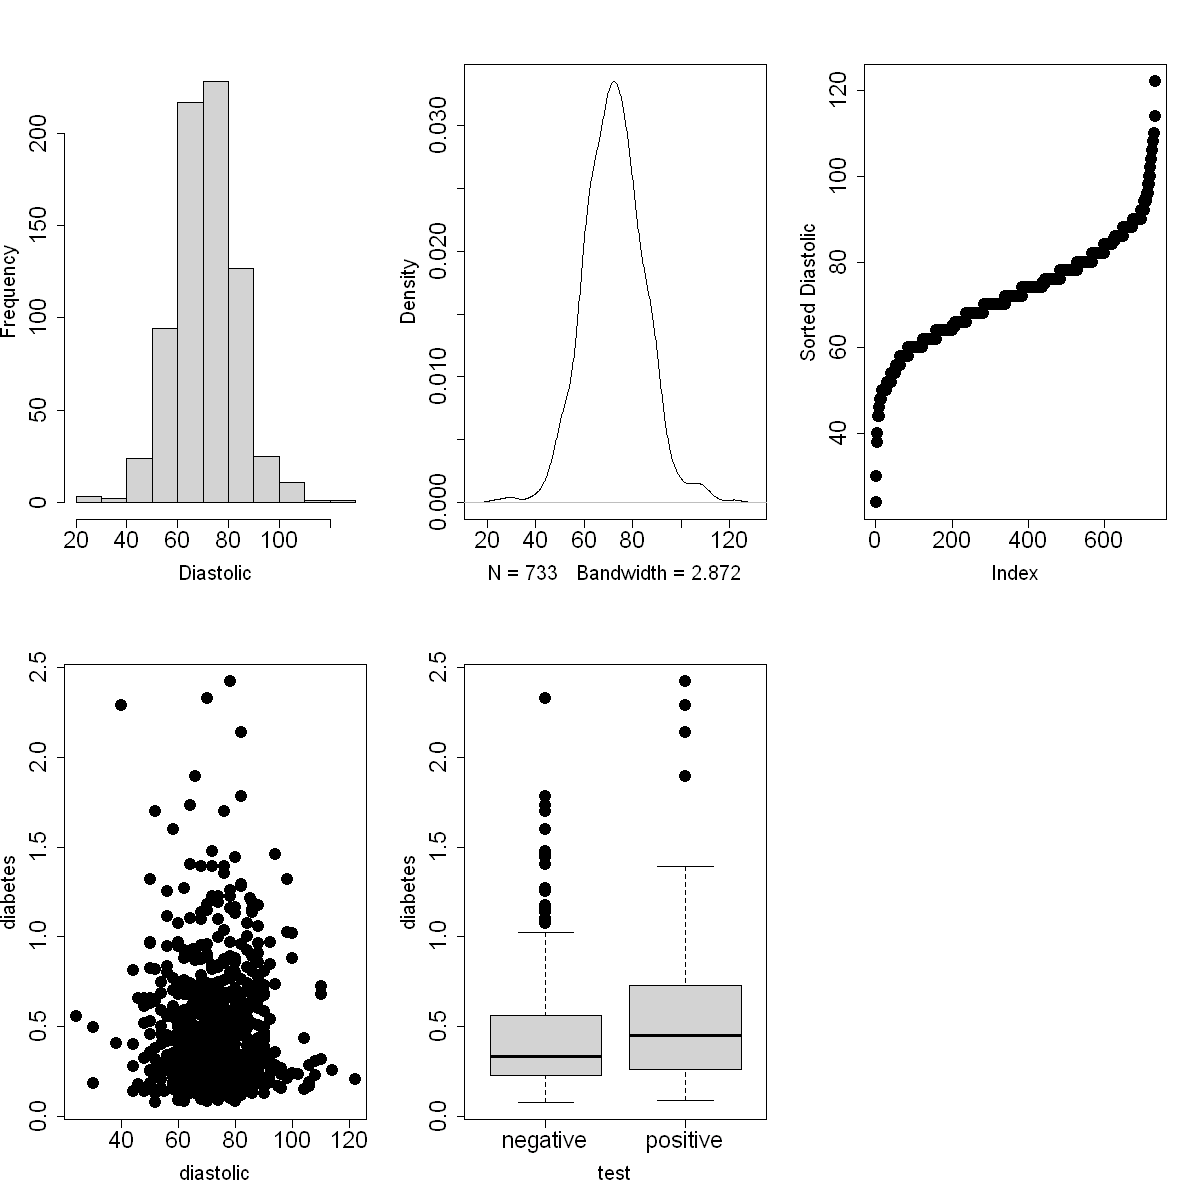

In [14]:
par(mfrow=c(2,3))
hist(pima$diastolic,xlab="Diastolic",main="",cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
plot(density(pima$diastolic,na.rm=TRUE),main="", cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
plot(sort(pima$diastolic),ylab="Sorted Diastolic",cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
plot(diabetes ~ diastolic,pima,cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
plot(diabetes ~ test,pima, cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
par(mfrow=c(1,1))

## Estimación

Los modelos lineales se utilizan para explicar la relación entre una variable dependiente $Y$ y una o más variables independientes $X_{1}, X_{2}, \dots; X_{p}$ (que también suelen llamarse variables predictoras o explicatorias). El subíndice $p$ indica el número de predictores que intervienen en la relación.

Si $p=1$ se denomina regresión simple, si $p>1$ se llama regresión múltiple. Un aspecto importante a tener en cuenta es que $Y$ debe ser siempre una variable continua, mientras que las covariables $X$ pueden ser continuas, discretas o categóricas. El análisis de la regresión busca dos objetivos:

1. Predecir posibles respuestas dados unos valores específicos de los predictores
2. Evaluar el efecto de (o la relación entre) las variables explicativas o independientes y la variable de respuesta o dependiente

De manera general, el modelo puede expresarse de la forma:

$$
Y = f\left(X_{1},X_{2},\dots,X_{p}\right) + \varepsilon
$$

o bien

$$
Y = \beta_{0} + \beta_{1}X_{1} + \beta_{2}X_{2} + \dots + \beta_{p}X_{p} + \varepsilon
$$

y su correspondiente expresión matricial

$$
y = X\beta + \varepsilon
$$

En todos los casos, los valores $\beta$ son desconocidos; la estimación se basa en calcular dichos valores con base en los datos recolectados. Se trata de una operación algebraica que, dependiendo del número de parámetros y de observaciones, representa complejidad. Por lo tanto, el uso de herramientas computacionales es de gran utilidad.

### REGRESIÓN SIMPLE

* El valor esperado es:

$$
E \left[ Y|X \right] = \beta_{0} + \beta_{1} X
$$

* La Variable de Respuesta viene dada por:

$$
Y = \beta_{0} + \beta_{1} X + \varepsilon
$$

* Se busca minimizar:

$$
L = \sum_{i=1}^{n} \varepsilon_{i}^{2} = \sum_{i=1}^{n} \left( y_{i} - \beta_{0} - \beta_{1} x_{i} \right)^{2}
$$

* Los parámetros se calculan con:

$$
\widehat{\beta_{1}} = \frac{\sum_{i=1}^{n} x_{i}y_{i} - n\overline{X}\overline{Y}}{\sum_{i=1}^{n} x_{i}^{2} - n \overline{X}^{2}}
$$

$$
\widehat{\beta_{0}} = \overline{Y} - \widehat{\beta_{1}}\overline{X}
$$

### Propiedades de los Parámetros:

\begin{eqnarray}
E \left[ \widehat{\beta_{1}} \right] &=& \beta_{1}\\
E \left[ \widehat{\beta_{0}} \right] &=& \beta_{0}\\
Var \left( \widehat{\beta_{1}} \right) &=& \frac{\sigma^{2}}{\sum_{i=1}^{n} x_{i}^{2} - n \overline{X}^{2}}\\
Var \left( \widehat{\beta_{0}} \right) &=& \sigma^{2} \left[ \frac{1}{n} + \frac{\overline{X}^{2}}{\sum_{i=1}^{n} x_{i}^{2} - n \overline{X}^{2}} \right]
\end{eqnarray}

Ahora, para simplificar escritura consideremos

$$
S_{XX} = \sum_{i=1}^{n} x_{i}^{2} - n \overline{X}^{2} \text{ y } S_{XY} = \sum_{i=1}^{n} x_{i}y_{i} - n\overline{X}\overline{Y}
$$

Para estimar la varianza:

\begin{eqnarray}
SS_{E} &=& S_{YY} - \widehat{\beta_{1}}S_{XX} \\
E\left[ SS_{E} \right] &=& \left( n - 2 \right) \sigma^{2}\\
\widehat{\sigma}^{2} &=& \frac{SS_{E}}{n-2} = MS_{E}
\end{eqnarray}

Para contrastar las hipótesis:


\begin{equation}
H_{0}: \widehat{\beta_{k}} = \beta_{k}^{\ast} \qquad H_{1}: \widehat{\beta_{k}} \neq \beta_{k}^{\ast} \quad k=0,1
\end{equation}

Y los estadísticos de prueba son:

\begin{equation}
t_{\beta_{0}} = \frac{\widehat{\beta_{0}} - \beta_{0}^{\ast}}{\sqrt{MS_{E}/S_{XX}}} \qquad t_{\beta_{1}} = \frac{\widehat{\beta_{1}} - \beta_{1}^{\ast}}{\sqrt{MS_{E}\left( \frac{1}{n} + \frac{\overline{X}^{2}}{S_{XX}} \right)}}
\end{equation}


Sin embargo $\beta_{k}^{\ast}$ se desconoce, entonces

\begin{equation}
H_{0}: \widehat{\beta_{k}} = 0 \qquad H_{1}: \widehat{\beta_{k}} \neq 0 \quad k=0,1
\end{equation}

Si se descompone $S_{YY}$ se tiene:

\begin{equation}
S_{YY} = \sum_{i=1}^{n} \left( y_{i} - \overline{Y} \right)^{2} = SS_{R} + SS_{E}
\end{equation}

A partir del cual se obtiene:

\begin{equation}
F_{0} = \frac{SS_{R}/1}{SS_{E}/(n-2)} = \frac{MS_{R}}{MS_{E}}
\end{equation}

Que será el estadístico de contraste para la idoneidad del modelo

## REGRESIÓN MÚLTIPLE

* Modelo de Regresión Lineal Múltiple

\begin{equation}
y = \beta_{0} + \beta_{1} X_{1} + \beta_{2} X_{2} + \dots + \beta_{k} X_{k} + \epsilon
\end{equation}

* Modelo Observado

\begin{equation}
y_{j} = \beta_{0} + \sum_{i=1}^{k} \beta_{i} x_{ij} + \epsilon_{j}
\end{equation}

El modelo puede expresarse matricialmente:

\begin{equation}
\mathbf{y}_{n \times 1} = \mathbf{X}_{n \times k} \mathbf{\beta}_{k \times 1} + \mathbf{\epsilon}_{n \times 1}
\end{equation}

Siendo:

$$
\mathbf{y} = \begin{pmatrix}
y_{1} \\
\vdots \\
y_{n} \\
\end{pmatrix}
\qquad
\mathbf{X} = \begin{pmatrix}
1 & \left( x_{11} - \overline{x}_{1} \right) & \dots & \left( x_{k1} - \overline{x}_{k} \right) \\
\vdots & \vdots & \vdots & \vdots \\
1 & \left( x_{1n} - \overline{x}_{1} \right) & \dots & \left( x_{kn} - \overline{x}_{k} \right)\\
\end{pmatrix}
$$

$$
\mathbf{\beta} = \begin{pmatrix}
\beta_{0}\\
\beta_{1}\\
\vdots \\
\beta_{k}\\
\end{pmatrix}
\qquad
\mathbf{\epsilon} = \begin{pmatrix}
\epsilon_{1}\\
\vdots\\
\epsilon_{n}\\
\end{pmatrix}
$$

* Función de Pérdida

\begin{equation}
L = \mathbf{y y^{\prime}} - 2 \mathbf{\beta^{\prime} X^{\prime} y} + \mathbf{\beta^{\prime} X^{\prime} X\beta}
\end{equation}

* Se Obtiene

\begin{equation}
\mathbf{X X^{\prime} \widehat{\beta}} = \mathbf{X^{\prime} y}
\end{equation}

Luego:

* Parámetros

\begin{eqnarray}
\mathbf{\widehat{\beta}} &=& \left( \mathbf{X X^{\prime}} \right)^{-1} \mathbf{X^{\prime} y}\\
E \left[ \widehat{\beta} \right] &=& \beta\\
Cov \left( \widehat{\beta} \right) &=& \sigma^{2} \left( \mathbf{X X^{\prime}} \right)^{-1}
\end{eqnarray}

* Se suele contrastar

\begin{eqnarray*}
H_{0} &:& \beta_{1} = \beta_{2} = \dots = \beta_{k} = 0 \\
H_{1} &:& \beta_{i} \neq 0, \text{ para algún } i
\end{eqnarray*}

Igual que en la RLS, se tiene:

\begin{equation}
SS_{yy} = SS_{R} + SS_{E}
\end{equation}

Además se tiene:

\begin{eqnarray}
\frac{SS_{R}}{\sigma^{2}} &\sim& \chi^{2}_{k} \\
\frac{SS_{E}}{\sigma^{2}} &\sim& \chi^{2}_{n-k-1} 
\end{eqnarray}

Con lo anterior se considera el estadístico:

\begin{equation}
F_{0} = \frac{SS_{R}/k}{SS_{E}/(n-k-1)} = \frac{MS_{R}}{MS_{E}}
\end{equation}

Contrastándolo contra $F_{\alpha,k,n-k-1}$. Donde se emplean las siguientes identidades:

\begin{eqnarray}
SS_{E} &=& SS_{yy} - \sum_{i=1}^{k} \widehat{\beta}_{i}S_{iy}\\
SS_{R} &=& \sum_{i=1}^{k} \widehat{\beta}_{i}S_{iy}
\end{eqnarray}

* Para el Contraste de Parámetros:

\begin{eqnarray*}
H_{0} &:& \beta_{i} = 0\\
H_{1} &:& \beta_{i} \neq 0
\end{eqnarray*}

Se emplea:

\begin{equation}
t_{0} = \frac{\widehat{\beta}_{i}}{\sqrt{MS_{E}C_{ii}}}
\end{equation}

Donde $C_{ii}$ se obtiene de:

$$
\mathbf{X X^{\prime}} = \begin{pmatrix}
\boldsymbol{C_{11}} & C_{12} & \dots & C_{1n}\\
C_{21} & \boldsymbol{C_{22}} & \dots & C_{1n}\\
\vdots & \vdots & \vdots & \vdots \\
C_{n1} & C_{n2} & \dots & \boldsymbol{C_{nn}}
\end{pmatrix}
$$

### Ejemplo usando R

Vamos a continuar el ejemplo con los datos que hemos venido trabajando. Por cuestiones metodológicas debemos tomar una nueva muestra

Primero, se deben cargar los datos:

In [15]:
datos <- read.csv(url("https://www.dropbox.com/s/h56k6jupp4znytt/sp_uis_2016_2022.csv?dl=1"))
datos <- na.omit(datos)
head(datos)

,X,Genero,EstExterior,Periodo,Con.Pro,Departamento,Municipio,EstuArea,Matricula,PagoBeca,⋯,IN_D,CE,CE_D,PG,NBC.P,P.GLOBAL,Programa,Escuela,Facultad,Metodologia
,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
1,1,F,NO,2022,EK202250140493,SANTANDER,PIEDECUESTA,Area Rural,No pagó matrícula,Si,⋯,B1,174,3,180,84,91,Electrónica,E3T,Ing. Fisicomecánicas,Presencial
2,2,M,NO,2022,EK202250194639,SANTANDER,GÁMBITA,Cabecera Municipal,Entre 500 mil y menos de 1 millón,No,⋯,B1,128,2,155,58,65,Industrial,Industrial,Ing. Fisicomecánicas,Presencial
3,3,F,NO,2022,EK202250154993,SANTANDER,BUCARAMANGA,Cabecera Municipal,No pagó matrícula,No,⋯,B1,127,2,158,83,69,T. Social,T. Social,Ciencias Humanas,Presencial
4,4,M,NO,2022,EK202250145996,SANTANDER,FLORIDABLANCA,Cabecera Municipal,Entre 500 mil y menos de 1 millón,Si,⋯,B2,159,3,178,86,89,Derecho,Derecho,Ciencias Humanas,Presencial
5,5,M,NO,2022,EK202250125970,SANTANDER,BUCARAMANGA,Cabecera Municipal,Menos de 500 mil,Si,⋯,B1,120,2,159,49,70,Mecánica,Mecánica,Ing. Fisicomecánicas,Presencial
6,6,F,NO,2022,EK202250127698,SANTANDER,BUCARAMANGA,Cabecera Municipal,No pagó matrícula,Si,⋯,B2,157,3,183,96,92,Lic. L. Extranjeras,Idiomas,Ciencias Humanas,Presencial


In [16]:
dim(datos)

[1] 5748   40

In [17]:
print(names(datos))

 [1] "X"             "Genero"        "EstExterior"   "Periodo"      
 [5] "Con.Pro"       "Departamento"  "Municipio"     "EstuArea"     
 [9] "Matricula"     "PagoBeca"      "PagoCredito"   "PagoPadres"   
[13] "PagoPropio"    "Semestre"      "EduPadre"      "EduMadre"     
[17] "Estrato"       "SNIES"         "GrupoRef"      "MunicipioProg"
[21] "ProgDepto"     "ProgNivel"     "Metodo"        "RC"           
[25] "RC_D"          "LC"            "LC_D"          "CC"           
[29] "CC_D"          "IN"            "IN_D"          "CE"           
[33] "CE_D"          "PG"            "NBC.P"         "P.GLOBAL"     
[37] "Programa"      "Escuela"       "Facultad"      "Metodologia"  


In [18]:
# Organicemos los datos
library(dplyr)
datos <- datos %>% 
  mutate_if(is.character, factor)
  datos$PERIODO <- factor(datos$Periodo)
datos$N_RC <- factor(datos$RC_D)
datos$N_LC <- factor(datos$LC_D)
datos$N_CC <- factor(datos$CC_D)
datos$N_CE <- factor(datos$CE_D)
datos$N_IN <- factor(datos$IN_D)


Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [19]:
# Extraigamos una muestra
#install.packages('samplingbook')

In [20]:
library(samplingbook)
n <- sample.size.mean(e=0.01*mean(datos$PG), S=sd(datos$PG), level = 0.975, N = length(datos$PG))$n
n

Cargando paquete requerido: pps

Cargando paquete requerido: sampling

Cargando paquete requerido: survey

Cargando paquete requerido: grid

Cargando paquete requerido: Matrix

Cargando paquete requerido: survival


Adjuntando el paquete: 'survival'


The following objects are masked from 'package:sampling':

    cluster, strata


The following objects are masked from 'package:faraway':

    rats, solder



Adjuntando el paquete: 'survey'


The following object is masked from 'package:graphics':

    dotchart




[1] 747

In [21]:
muestra<- sample(1:nrow(datos), size=n, replace=FALSE)
m.datos<-datos[muestra,]

In [22]:
dim(m.datos)

[1] 747  46

Lo correcto es iniciar con el planteamiento del problema. Para efectos del ejercicio se seleccionarán dos variables: `RC` y `LC`.
Se busca establecer si el puntaje obtenido en RC puede ser explicado por el puntaje obtenido en LC.
Lo siguiente es realizar un análisis exploratorio con las variables seleccionadas:

In [23]:
# Un resumen numérico
varsel<-m.datos[,c('RC','LC')]
summary(varsel)

       RC              LC       
 Min.   : 75.0   Min.   : 70.0  
 1st Qu.:159.5   1st Qu.:154.0  
 Median :181.0   Median :175.0  
 Mean   :179.5   Mean   :170.9  
 3rd Qu.:203.0   3rd Qu.:191.0  
 Max.   :300.0   Max.   :232.0  

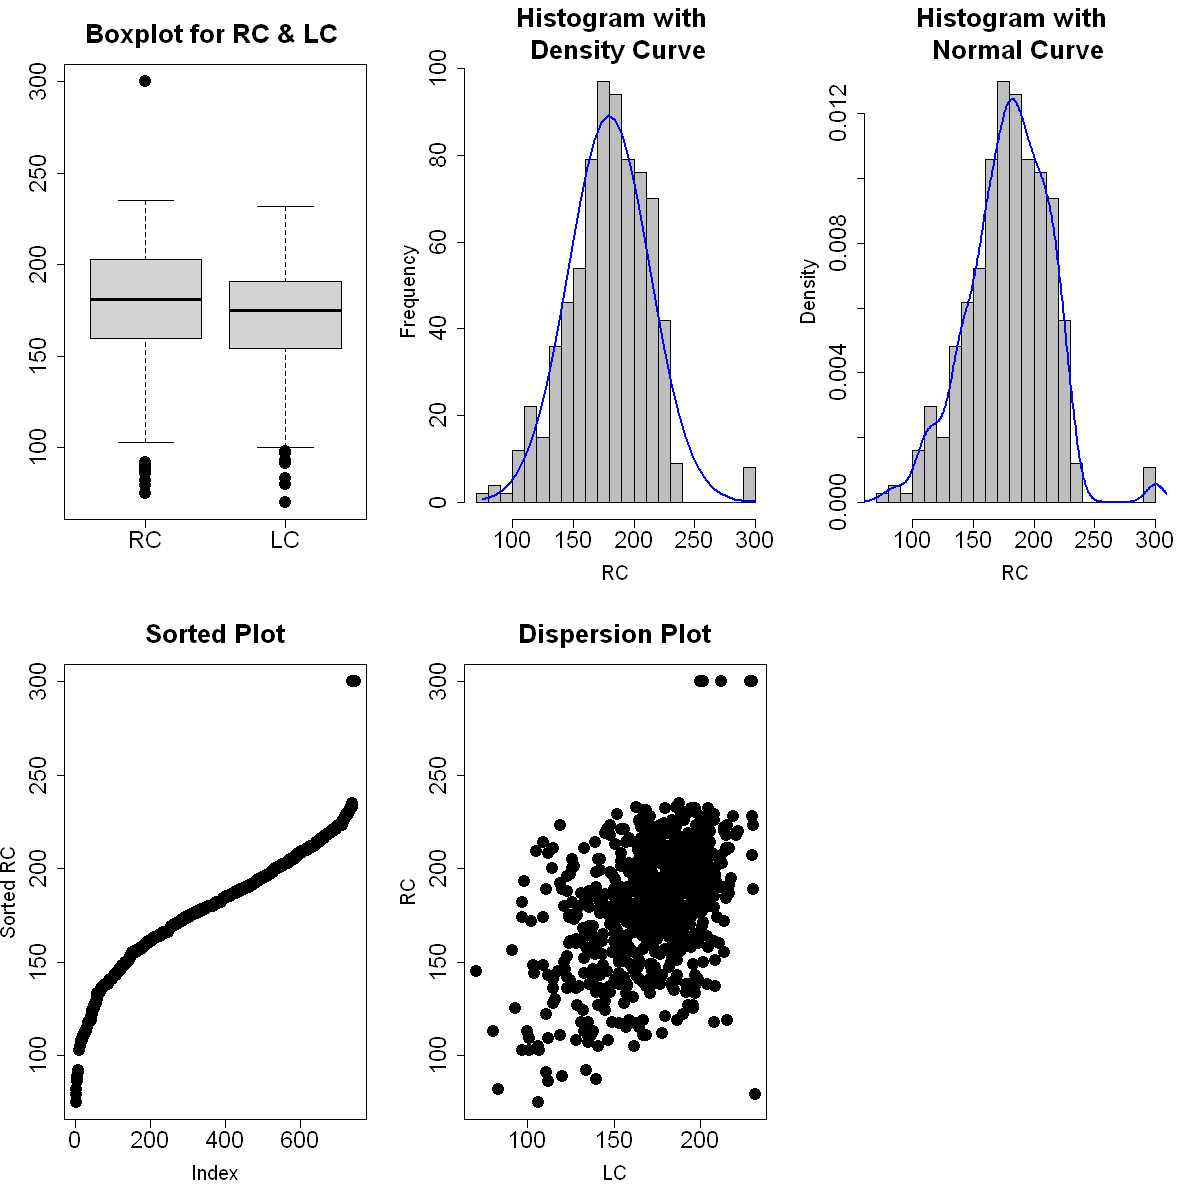

In [24]:
# Algunos gráficos exploratorios
par(mfrow=c(2,3))

x <- varsel$RC

boxplot(varsel, main="Boxplot for RC & LC ", cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)

h<-hist(x, breaks=25, col="grey", xlab="RC", main="Histogram with \n Density Curve", cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
xfit<-seq(min(x), max(x), length=40)
yfit<-dnorm(xfit, mean=mean(x), sd=sd(x))
yfit <- yfit*diff(h$mids[1:2])*length(x)
lines(xfit, yfit, col="blue", lwd=2)

h<-hist(x, freq = F, breaks=25, col="grey", xlab="RC", main="Histogram with \n Normal Curve",cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
lines(density(x), col="blue", lwd=2)

plot(sort(x),ylab="Sorted RC", main = "Sorted Plot",cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)

with(m.datos, plot(LC,RC, main = "Dispersion Plot",cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2))

par(mfrow=c(1,1))

Ahora, se procede a estimar el modelo.
El comando `lm()` hace referencia a la estimación de los modelos lineales; contiene dos elementos importantes en sus argumentos: `formula` y `data`. La primera describe la relación que se ha planteado para las variables donde la virgulilla (`~`) denota la dependencia; así, para el caso específico del ejercicio, debe escribirse: `RC~LC`, y en el segundo argumento debe declararse el conjunto de datos del cual se toman las variables: `data = varsel` o, si se desea: `data = m.datos` ya que el primer conjunto de datos corresponde a una selección de variables del segundo.
El comando `sumary` de la libreía `faraway` permite mostrar los estadísticos más relevantes para esta parte del ejercicio:

In [25]:
fit<-lm(RC ~ LC, data = varsel)
library(faraway)
sumary(fit)

            Estimate Std. Error t value  Pr(>|t|)
(Intercept) 89.87853    6.83548  13.149 < 2.2e-16
LC           0.52427    0.03948  13.279 < 2.2e-16

n = 747, p = 2, Residual SE = 30.07625, R-Squared = 0.19


O bien, ver el resumen numérico del modelo completo:

In [26]:
summary(fit)


Call:
lm(formula = RC ~ LC, data = varsel)

Residuals:
     Min       1Q   Median       3Q      Max 
-132.510  -18.471    1.141   19.884  105.267 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 89.87853    6.83548   13.15   <2e-16 ***
LC           0.52427    0.03948   13.28   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 30.08 on 745 degrees of freedom
Multiple R-squared:  0.1914,	Adjusted R-squared:  0.1903 
F-statistic: 176.3 on 1 and 745 DF,  p-value: < 2.2e-16


Del estadístico `F` se desprende el análisis de la Varianza:

In [27]:
summary(aov(fit))

             Df Sum Sq Mean Sq F value Pr(>F)    
LC            1 159517  159517   176.3 <2e-16 ***
Residuals   745 673913     905                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Ahora, se pueden graficar los intervalos de confianza:

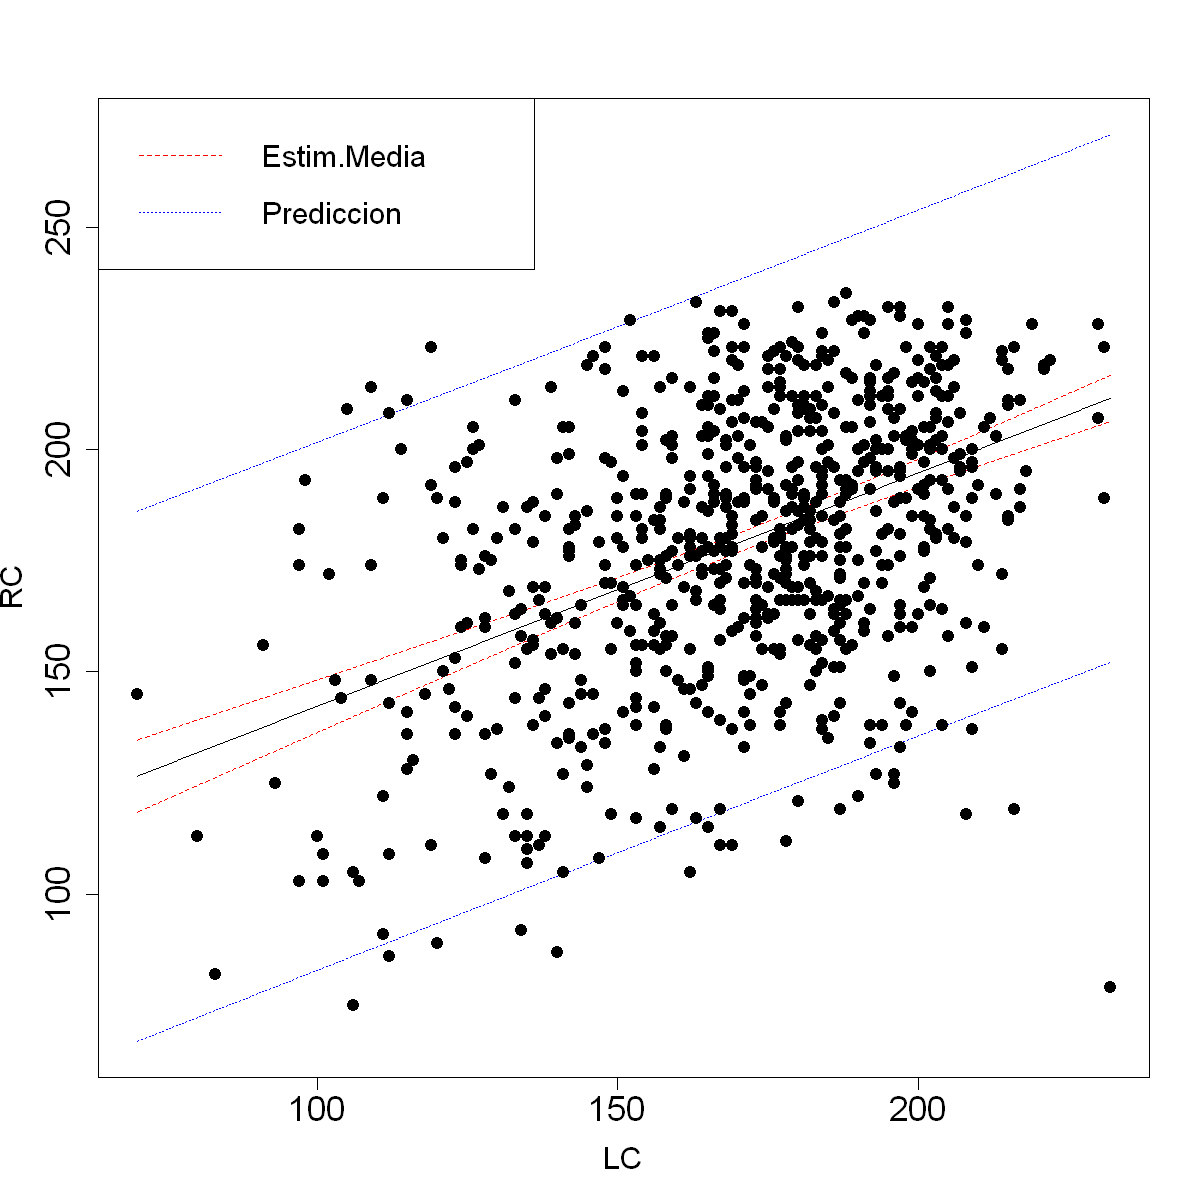

In [28]:
x0<-seq(min(varsel$LC),max(varsel$LC),length=length(varsel$LC))
pred.m<-predict(fit,data.frame(LC=x0),interval="confidence",se.fit=T)
pred.p<-predict(fit,data.frame(LC=x0),interval="prediction",se.fit=T)

matplot(x0,cbind(pred.m$fit,pred.p$fit[,-1]),lty=c(1,2,2,3,3),
        col=c("black","red","red","blue","blue"),type="l",xlab="LC",
        ylab="RC", cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)

legend('topleft',c("Estim.Media","Prediccion"),lty=c(2,3),
       col=c("red","blue"), cex = 1.5)

points(varsel$LC,varsel$RC, pch = 20, cex = 2)

# Recordemos

De manera general, es posible representar el modelo lineal de la forma

$$
y_{i}|x_{i} \overset{iid}{\sim} N \left( x_{i}^{\prime} \beta , \sigma^{2} \right), \; i = 1, \dots, n
$$

con $x_{i}^{\prime} = \left( 1,x_{1i}, \dots , x_{i,p-1} \right)$

En ese orden de ideas, se observa que las covariables pueden presentar diferentes características; pueden ser continuas o categóricas. Según eso, la interpretación del modelo varía. En el primer caso, cuando se tiene variables de tipo continuo, el objetivo de los modelos es, generalmente, predictivo. En el caso de las variables categóricas se tratan objetivos  de comparación de grupos.

Deben considerarse algunos aspectos de la sintaxis anterior:

La línea `x0<-seq(min(varsel$LC),max(varsel$LC),length=length(varsel$LC))` presenta algunos argumentos clave en el cálculo de las nuevas medidas. En el caso particular del ejemplo, se trata de una secuencia que va del valor mínimo de la variable independiente (en este caso la denominada `LC`, al valor máximo de la misma y cuya longitud `length` es de 681 ya que la tabla original de datos tiene 681 observaciones.

Hay que recordar que, en este punto, se requiere plantear las respectivas pruebas de hipótesis para los parámetros $\beta$ del modelo. De manera general, se tiene:

$$
H_{0}: \beta_{k} = 0 \\
H_{1}: \beta_{k} \neq 0
$$

Se se establece un nivel de significancia $\alpha = 0.05$; se observa que $\beta_{0}$ y $\beta_{1}$ son significativos.

Otro elemento a evaluar es la varianza que es lo que, en verdad, permite determinar si la variación observada se debe a la regresión. La prueba de Análisis de la Varianza (ANOVA) tiene como base las hipótesis:

$$
H_{0}: \sigma^{2} = 0 \\
H_{1}: \sigma^{2} > 0
$$

que tiene su respectiva interpretación como se discutió en el curso. Para realizar el análisis de la varianza, una opción es:

In [29]:
aov.fit<-aov(fit)
summary(aov.fit)

             Df Sum Sq Mean Sq F value Pr(>F)    
LC            1 159517  159517   176.3 <2e-16 ***
Residuals   745 673913     905                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Ahora, se tiene evidencia que la regresión explica bien la variación observada en la variable dependiente (recuérdese lo discutido en el curso).

Para el diagnóstico del modelo es bueno realizar una inspección gráfica. El modelo estimado permite desarrollar un diagnóstico inicial en el cual se profundizará al momento de abordar el enfoque múltiple:

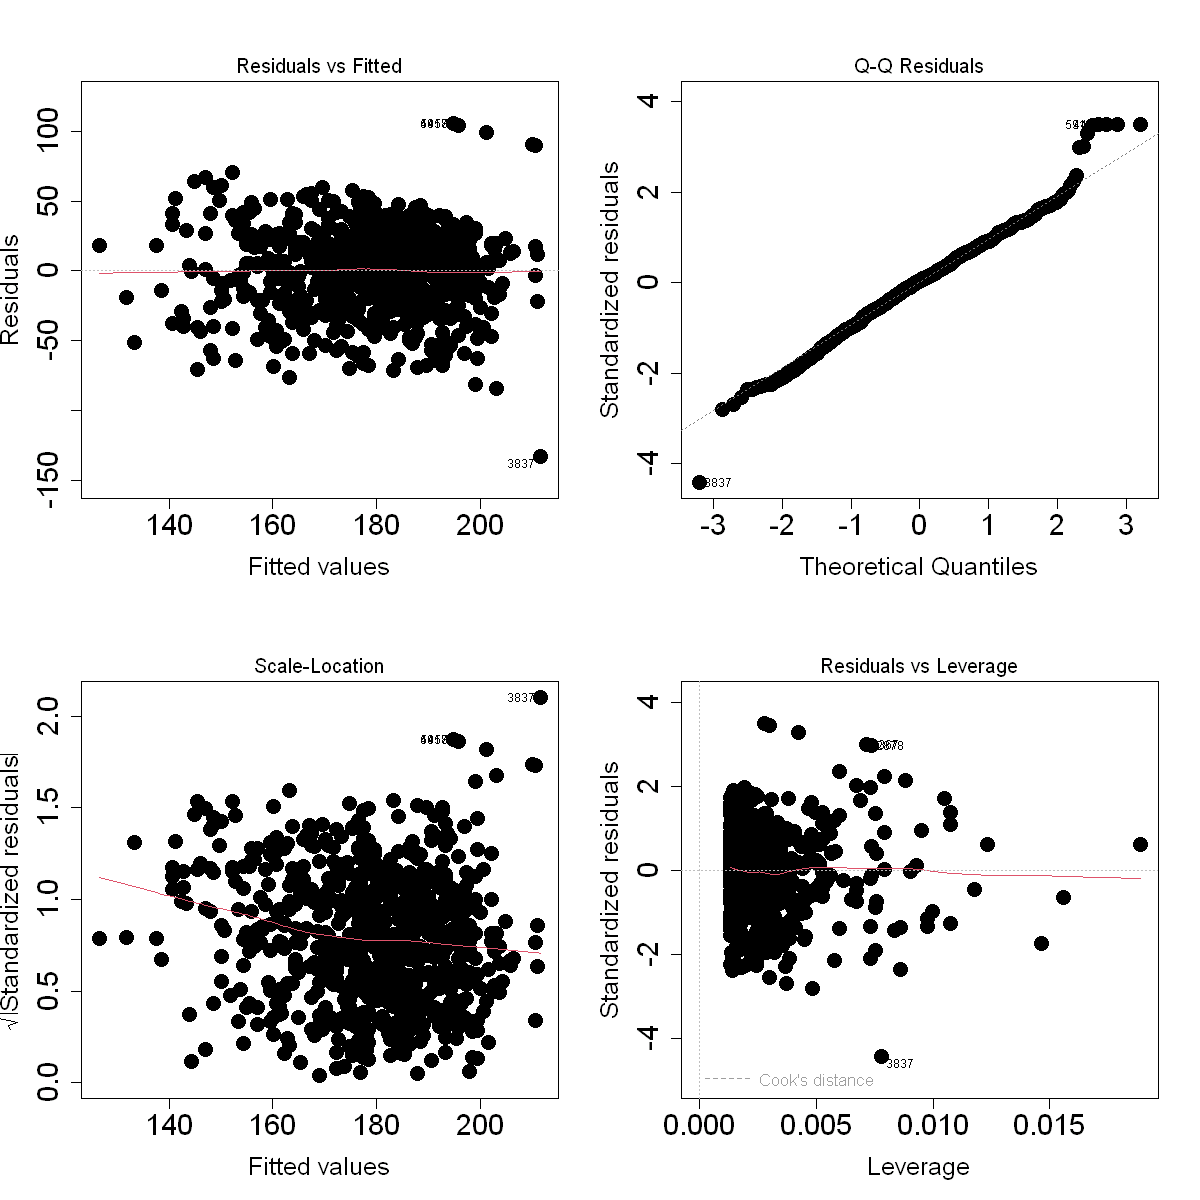

In [30]:
par(mfrow = c(2,2))
plot(fit,cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
par(mfrow = c(1,1))

Mediante esta salida es posible revisar parte del cumplimiento de los supuestos. Sin embargo, se requiere de la realización de las respectivs pruebas para concluir al respecto.

Para este análisis, se emplean los residuales. Así, los residuos $e(i)$ se obtienen:

In [31]:
e<-residuals(fit)
print(round(e,2)) # en esta última línea la orden round se refiere al redondeo de cifras significativas

   4284    3437    2607    3775    5844    3216    2994     820    1995    1508 
 -35.82    6.53  -26.07   22.22  -51.39  -60.16   41.27   -3.40    9.00   50.38 
   3125    2668    1141    2491    2079    2476    1569    3668    5320    6095 
   7.66   66.98   11.38   18.42   12.28  -65.64    3.94   24.04   15.40   -8.24 
   3028    4085      51    3107    3692      37    5655    4843    4659    4340 
 -28.67   10.94  -39.19   21.51    0.60  -19.82   20.79   23.66    2.18    3.66 
   2993    5149    4682    4708    4269    5268     157    4082    5973    5026 
 -46.53  -11.20  -62.45   37.80   21.65  -10.57  -29.34  -31.73   26.17   27.22 
   1133    1625    4747    1993    3849    4243    3782    4447    2998    4828 
 -64.06  -12.92   17.49  -13.00  -36.80  -30.78   27.03   21.27  -12.65   20.41 
   4281     353     893    3652    2036    5750    4949    4923    3648    1229 
  50.53   70.73    7.40  -10.11   10.13   43.47  -48.99  -14.72  -26.09   14.36 
   2964    2270    4368    3

Y los residuos estandarizado con

In [32]:
sfit<-summary(fit)
d<-e/sfit$sigma
print(round(d,2))

 4284  3437  2607  3775  5844  3216  2994   820  1995  1508  3125  2668  1141 
-1.19  0.22 -0.87  0.74 -1.71 -2.00  1.37 -0.11  0.30  1.68  0.25  2.23  0.38 
 2491  2079  2476  1569  3668  5320  6095  3028  4085    51  3107  3692    37 
 0.61  0.41 -2.18  0.13  0.80  0.51 -0.27 -0.95  0.36 -1.30  0.72  0.02 -0.66 
 5655  4843  4659  4340  2993  5149  4682  4708  4269  5268   157  4082  5973 
 0.69  0.79  0.07  0.12 -1.55 -0.37 -2.08  1.26  0.72 -0.35 -0.98 -1.06  0.87 
 5026  1133  1625  4747  1993  3849  4243  3782  4447  2998  4828  4281   353 
 0.90 -2.13 -0.43  0.58 -0.43 -1.22 -1.02  0.90  0.71 -0.42  0.68  1.68  2.35 
  893  3652  2036  5750  4949  4923  3648  1229  2964  2270  4368  3973  2319 
 0.25 -0.34  0.34  1.45 -1.63 -0.49 -0.87  0.48  0.89  0.89 -0.66 -1.28 -0.09 
 1487  5137  2058  1149  5565  3069  3073  5045  5506  2004  4919  2394  5743 
-0.70  0.90  0.31 -0.94  1.11  0.06 -1.45 -0.18 -0.51 -0.61  0.00 -1.15 -0.11 
 2919  6204  6256  2704   373  4527  5757  1786  169

o bien con una función de la librería `MASS` llamada `stdres`

In [33]:
library(MASS)
print(stdres(fit))


Adjuntando el paquete: 'MASS'


The following object is masked from 'package:dplyr':

    select




        4284         3437         2607         3775         5844         3216 
-1.191931588  0.217332701 -0.870163611  0.739853707 -1.721412146 -2.002771856 
        2994          820         1995         1508         3125         2668 
 1.379512805 -0.113343171  0.299281835  1.676729789  0.254742609  2.235757277 
        1141         2491         2079         2476         1569         3668 
 0.378837834  0.618387878  0.408485734 -2.184965981  0.131043264  0.799968965 
        5320         6095         3028         4085           51         3107 
 0.513337732 -0.274112890 -0.954068326  0.364039340 -1.304085249  0.715880668 
        3692           37         5655         4843         4659         4340 
 0.019891276 -0.659526510  0.692223695  0.787159283  0.072530472  0.121638441 
        2993         5149         4682         4708         4269         5268 
-1.548071985 -0.372617097 -2.080435295  1.257738113  0.720901488 -0.351712552 
         157         4082         5973         5026 

Una aproximación gráfica de los residuos permite analizar los distintos supuestos. Como éstos parten de la consideración $e \sim N(0,\sigma^{2})$, es neceseario dedicarle un momento a revisar este aspecto.

En el primer gráfico, el histograma se contrasta con la forma de campana que sigue un distribución normal. La distribución de la densidad de los residuos estandarizados presenta un pequeño sesgo en relación con la campana de normalidad. 

El segundo gráfico es de residuos estandarizados versus el predictor. Este muestra poca linealidad en la distribución de los residuos pues se evidencia perturbación en los residuos a partir de cierta magnitud de la variable regresora.

El tercer gráfico es de la secuencia temporal de los residuos estandarizados y muestra poca reguralidad en su distribución. 

El último gráfico es el de residuos estandarizados rezagados y tiene una distribución bastante dispersa, por lo tanto, hay independencia entre los residuos.

La sintaxis para esto es:

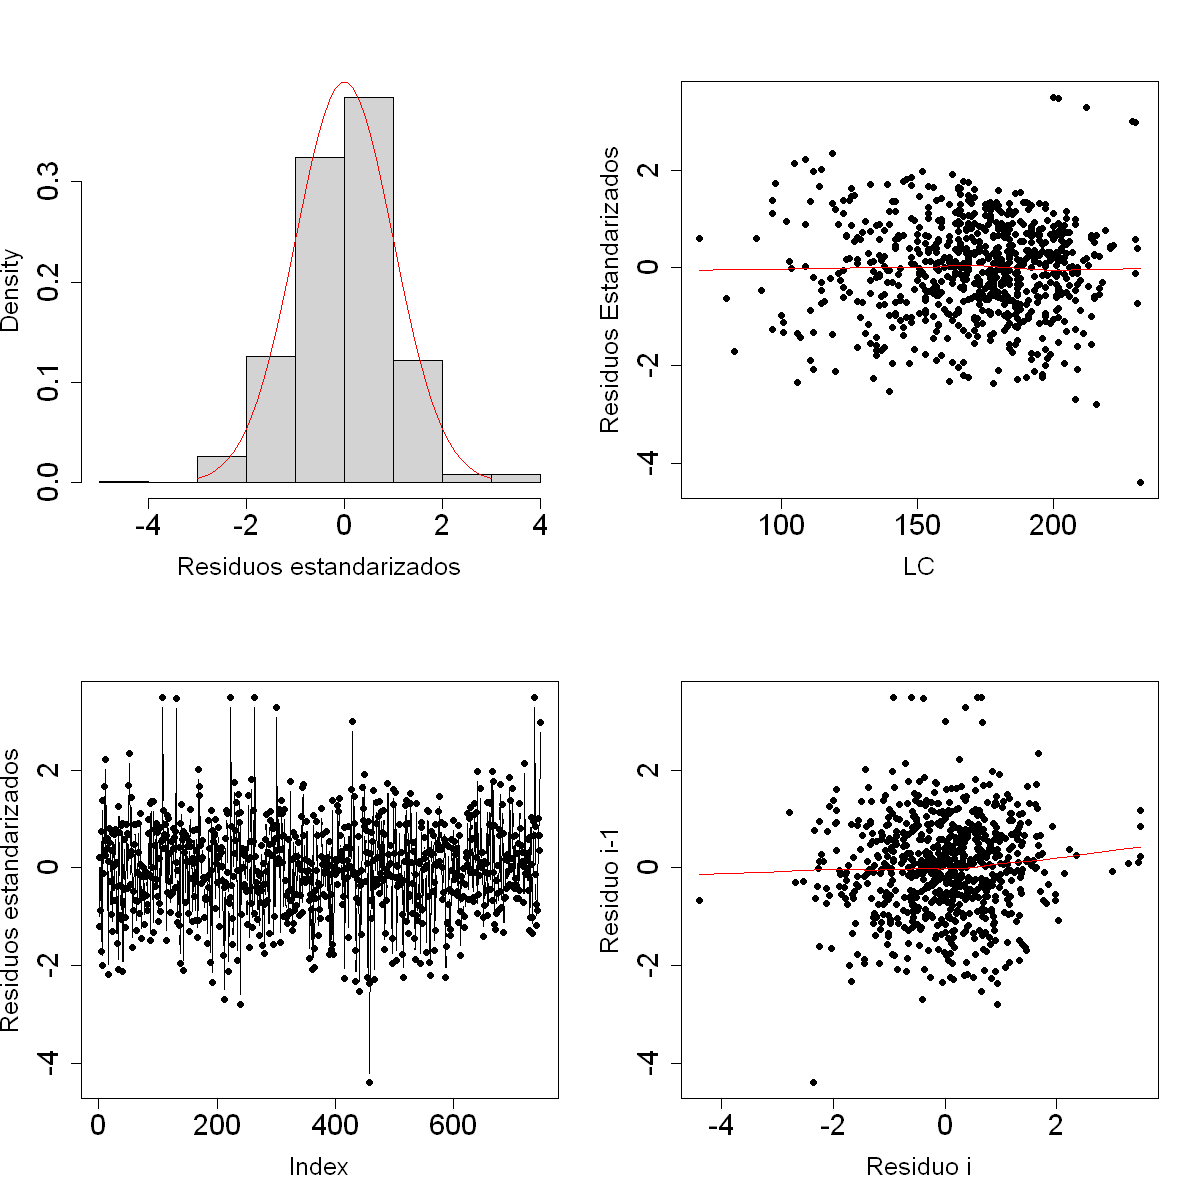

In [34]:
par(mfrow=c(2,2))
# el histograma de los residuos, superponiendo una densidad normal:
hist(d,probability=T,xlab="Residuos estandarizados",main="",
     cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
d.seq<-seq(-3,3,length=50)
lines(d.seq,dnorm(d.seq,mean(d),sd(d)), col = 'red')

# El gráfico de residuos versus el predictor:
plot(varsel$LC,d,xlab="LC",ylab="Residuos Estandarizados",cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)

# y se ajusta con una curva suavizada la tendencia:
lines(lowess(varsel$LC,d),col="red")

# La secuencia temporal de residuos se obtiene con:
plot(d,type="b",ylab="Residuos estandarizados", cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)

# y el gráfico de residuos versus el anterior es:
n<-length(d)
plot(d[1:(n-1)],d[2:n],xlab="Residuo i",ylab="Residuo i-1",cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)

# y se ajusta con una curva suavizada la tendencia:
lines(lowess(d[1:(n-1)],d[2:n]),col="red")

El gráfico _Normal Q-Q plot_ presenta los cuantiles de residuos de la muestra contra los cuantiles teóricos. La línea de normalidad hace referencia a cómo se deberían comportar los residuos en caso que siguieran una distribución normal. Si se alejan lo suficiente de la línea teórica puede suponer que hay heterocedasticidad. Además, si la gráfica muestra algunos datos atípicos puede implicar _ruido_ en el modelo.

El _Boxplot_ de los residuos (no estandarizados) deja en manifiesto la dispersión de los datos y la presencia de valores atípicos. Se completa la exploración con el boxplot _con outliers_ para la variable dependiente y, luego, la gráfica _sin outliers_. 

In [35]:
#install.packages('outliers')

[1] 300

[1]  82 300 300  75  89 300  91 300 300  86  92 300  87  79 300 300

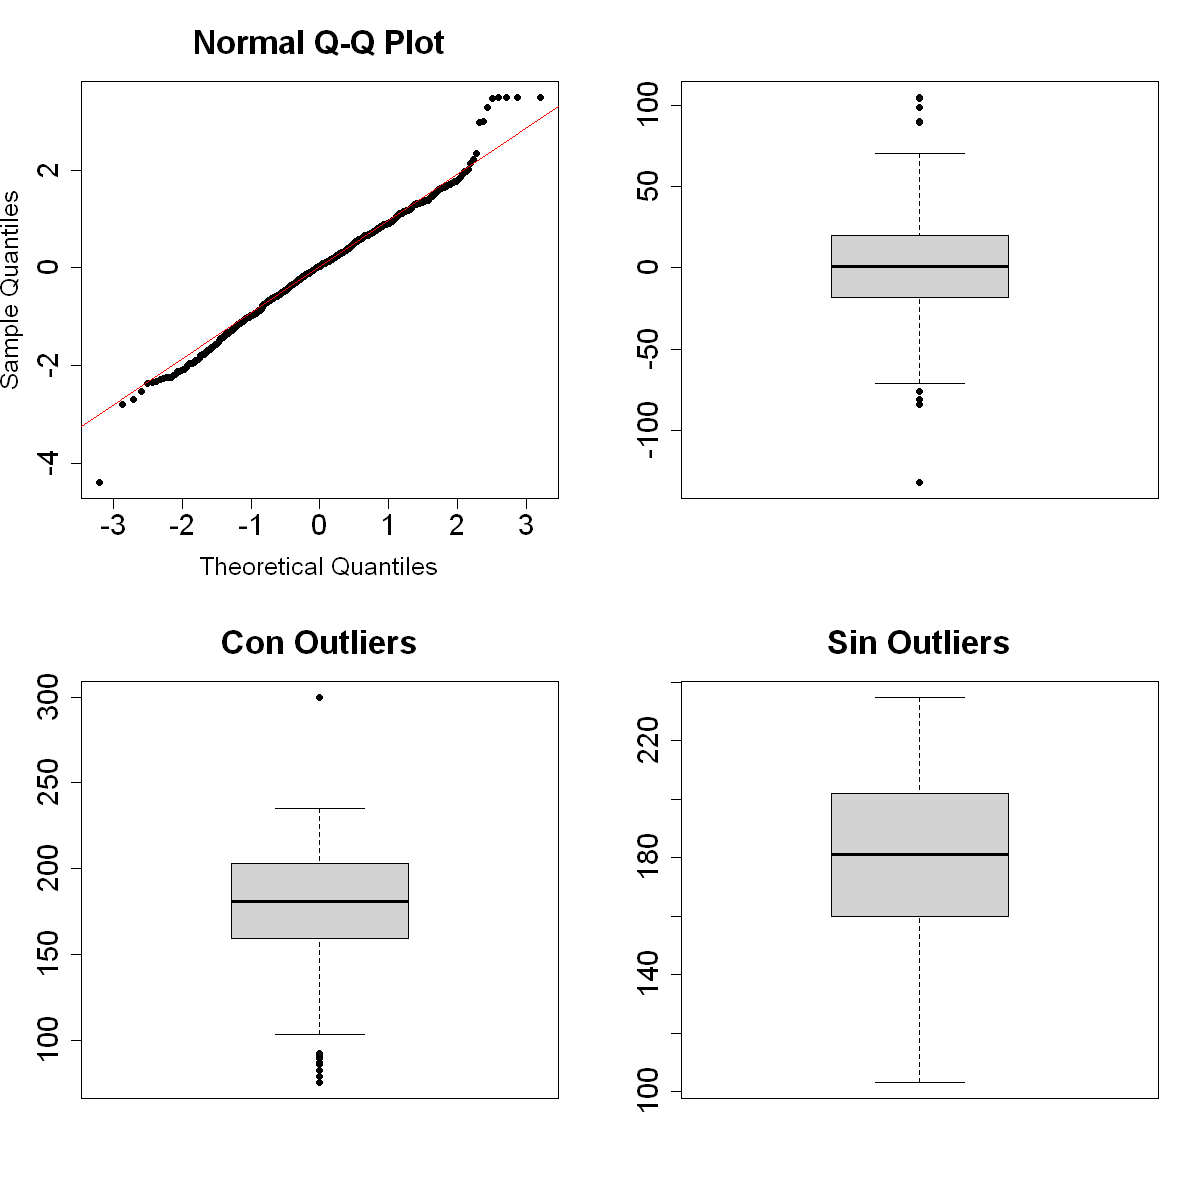

In [36]:
par(mfrow=c(2,2))

# Datos Atípicos:
# Conseguir los gr¶aficos qqplot de normalidad con los comandos:
qqnorm(d,cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)
qqline(d, col = 'red')
boxplot(e,cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)

library(outliers)

outlier(m.datos$RC)
boxplot(m.datos$RC,cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2, main = 'Con Outliers')$out
outliers <- boxplot(m.datos$RC, plot=FALSE)$out
var.no.out <- m.datos[-which(m.datos$RC %in% outliers),]

boxplot(var.no.out$RC, main = 'Sin Outliers', cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)

Los intervalos de confianza de los parámetros son:

In [37]:
ic.ind<-confint(fit,level=0.95)
print(ic.ind)

                 2.5 %      97.5 %
(Intercept) 76.4594344 103.2976173
LC           0.4467667   0.6017772


In [38]:
alpha <- 0.05
estim<-fit$coefficients
error<-sfit$coefficients[,2]
p<-length(estim)
t.alpha<-qt(1-alpha/(2*p),df.residual(fit))
ic.bonf4<-cbind(inf=estim-t.alpha*error,sup=estim+t.alpha*error)
ic.bonf4

,inf,sup
(Intercept),74.5264359,105.2306159
LC,0.4356022,0.6129417


In [39]:
alpha<-0.05
t.alpha<-qt(1-alpha/(2),df.residual(fit))
ic.bonf2<-cbind(inf=estim-t.alpha*error,sup=estim+t.alpha*error)
ic.bonf2

,inf,sup
(Intercept),76.4594344,103.2976173
LC,0.4467667,0.6017772


La gráfica del modelo versus la variable predictora:

La comprobación de los supuestos requiere de exploración gráfica y de implementación de pruebas estadísticas. Cada supuesto tiene su respectiva forma de revisión. El primer supuesto para abordar es el de linealidad. Para ello se puede emplear la gráfica de la variable independiente vs. los residuos parciales. Puede emplearse la función `prplot`:

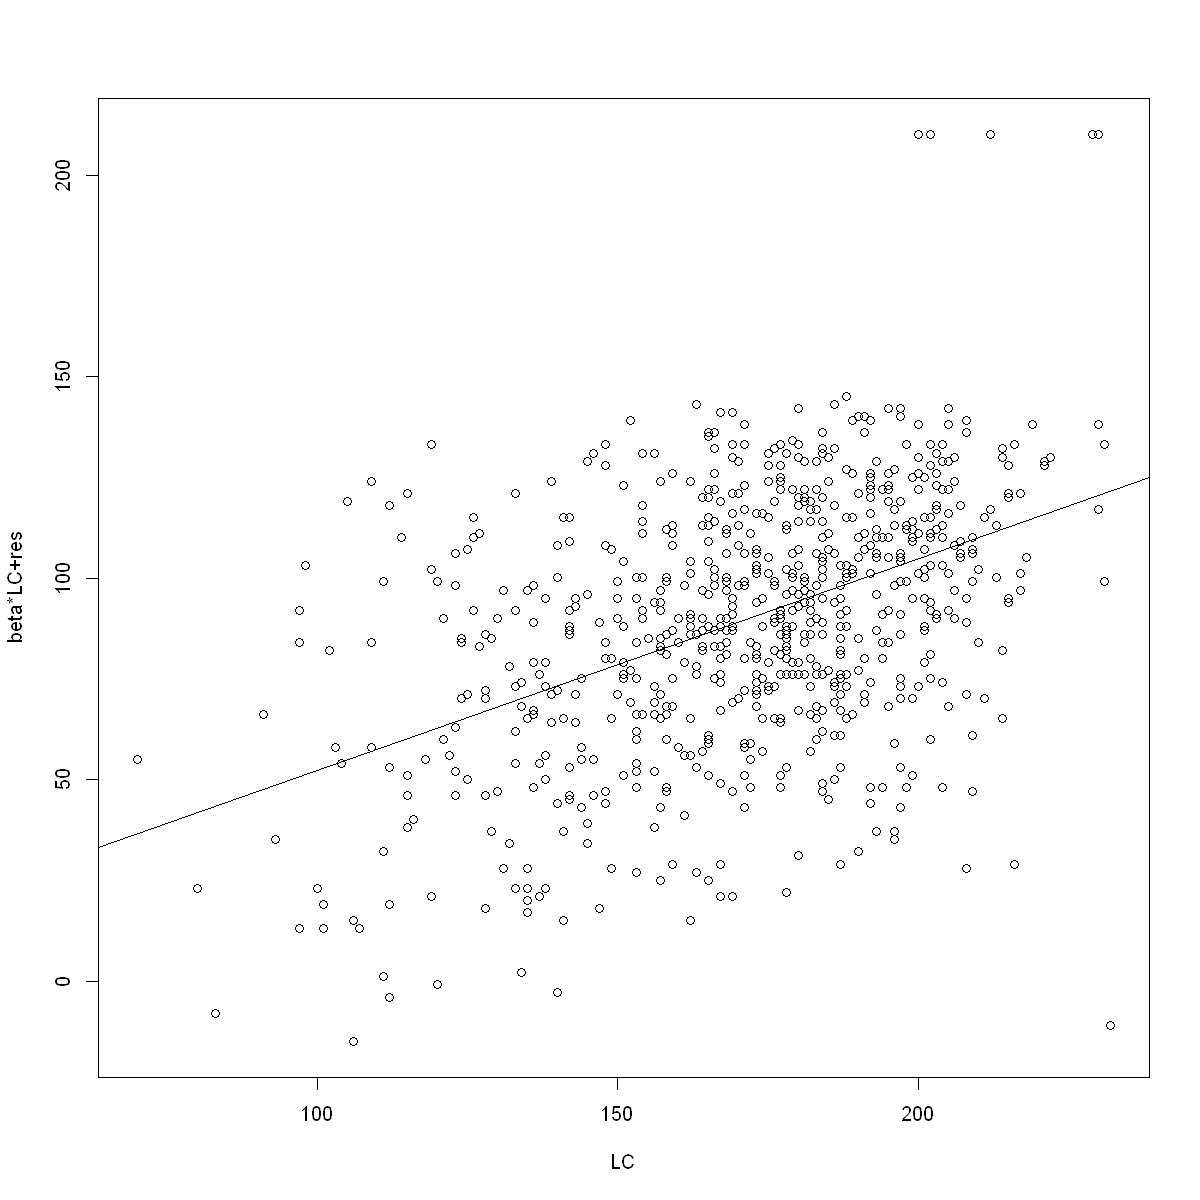

In [40]:
# Usando Residuos Parciales
prplot(fit,1)

Algo a considerar al momento de implementar las pruebas para comprobación de supuestos es que, en las pruebas de hipótesis respectivas, la hipótesis nula se plantea en función del cumplimiento del supuesto. Por ejemplo, para el supuesto de homocedasticidad:

$$
H_{0} : \text{El modelo es Homocedástico}\\
H_{1} : \text{El modelo es Heterocedástico}
$$

El supuesto de homocedasticidad se puede verificar primero con la exploración gráfica:

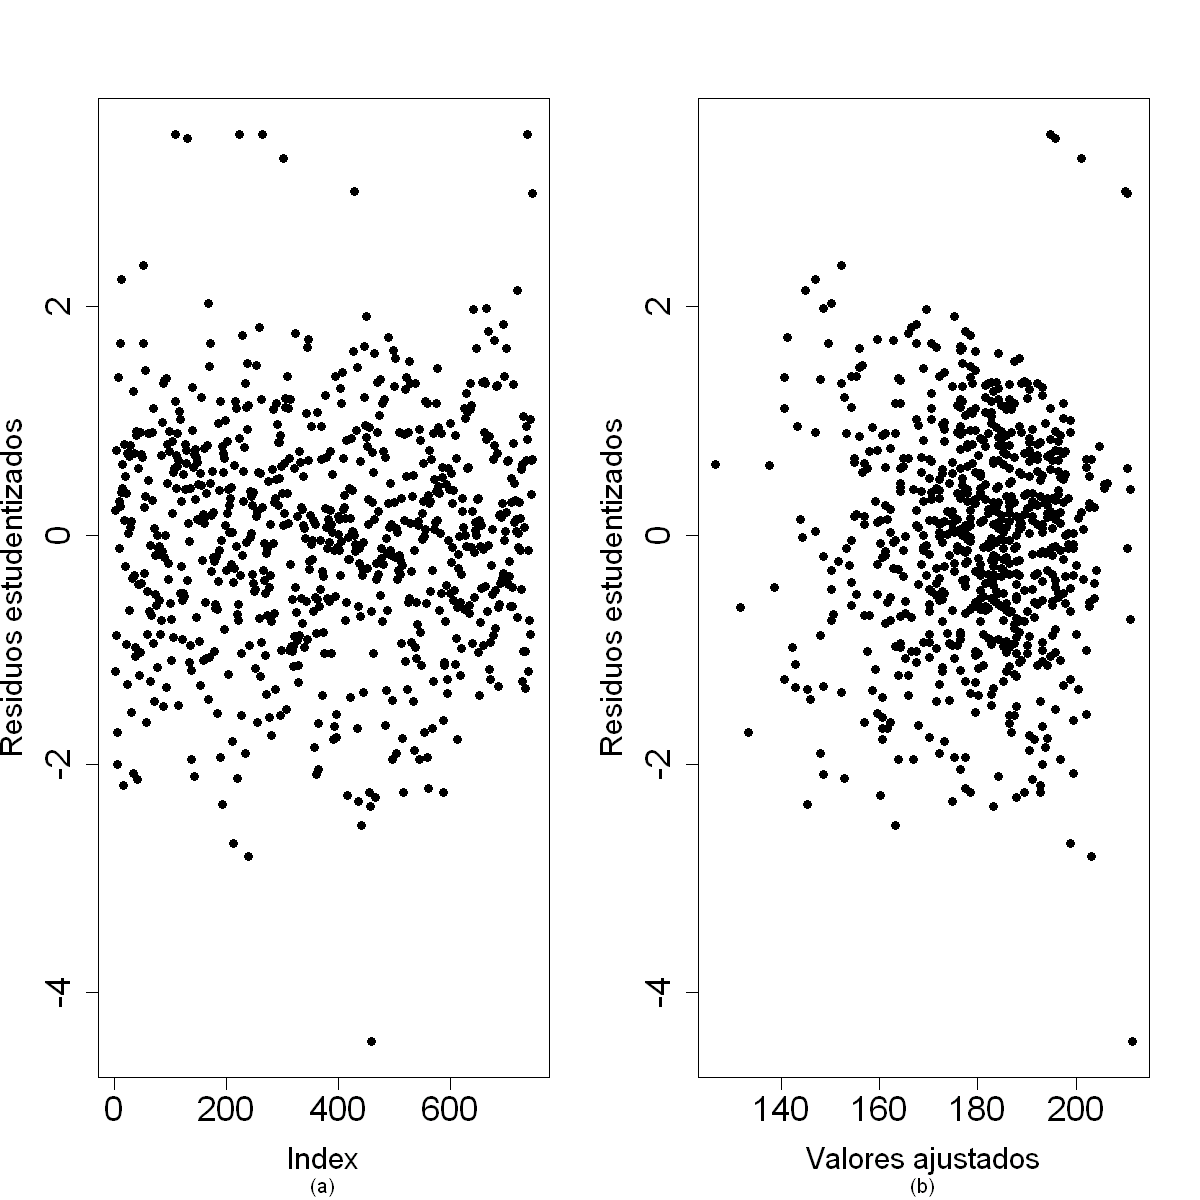

In [41]:
r<-rstandard(fit)
opar<-par(mfrow=c(1,2))
# los residuos solos
plot(r,ylab='Residuos estudentizados', cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)
title(sub="(a)")
# los residuos versus los valores ajustados
plot(fitted(fit),r,xlab='Valores ajustados',
     ylab='Residuos estudentizados', cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)
title(sub="(b)")
par(opar)

Matemáticamente, hay varias pruebas para la comprobación del supuesto, una de ellas es el test de _Breusch-Pagan_ que se puede implementar usando la función `bptest` de la librería `lmtest`:

In [42]:
#install.packages('lmtest')

In [43]:
library(lmtest)
# El test de Breusch-Pagan se obtiene con (supuesto de HOMOCEDASTICIDAD)
bptest(fit)

Cargando paquete requerido: zoo


Adjuntando el paquete: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  fit
BP = 0.050619, df = 1, p-value = 0.822


El supuesto de normalidad se ha explorado anteriormente. Cabe recordar, entonces, que las gráficas recomendadas (aunque no las únicas) son el histograma y el gráfico de cuantiles (_QQ-Plot_):

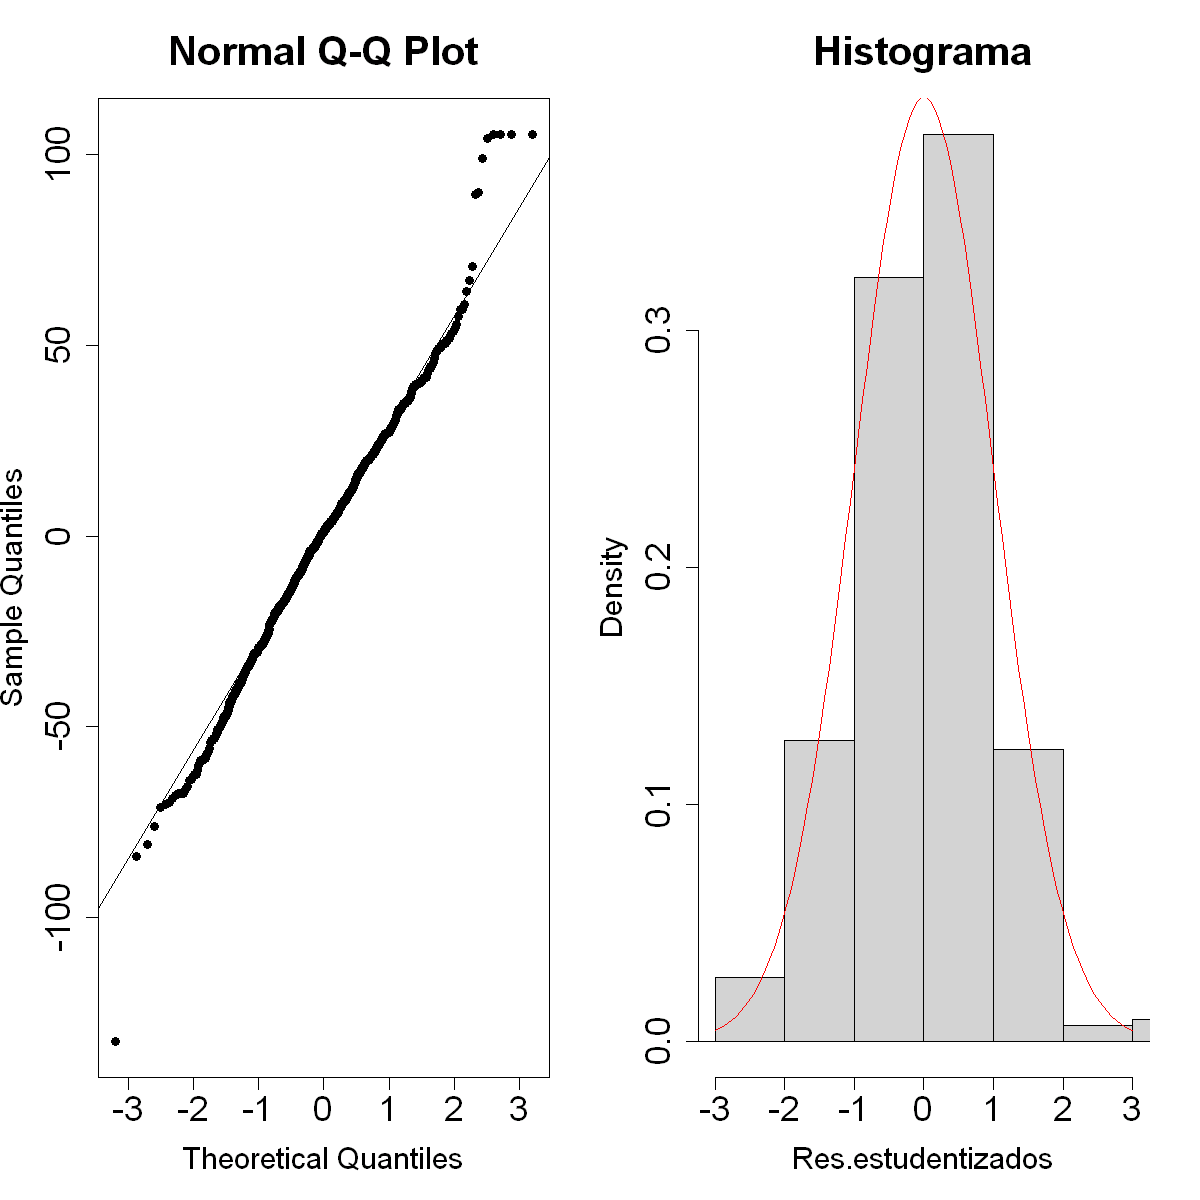

In [44]:
opar<-par(mfrow=c(1,2))
# Los gráficos de normalidad para los residuos son
qqnorm(fit$resid, cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)
qqline(fit$resid)
# Eln histograma y superponer una densidad normal para los residuos estandarizados o estudentizados
r<-rstandard(fit)
hist(r,prob=T,xlim=c(-3,3),xlab="Res.estudentizados",main="Histograma", cex.lab=1.5, cex.axis=1.75, cex = 2, pch = 19, cex.main = 2)
lines(xseq<-seq(-3,3,length=100), dnorm(xseq,mean(r),sd(r)),
      col = 'red')
par(opar)

In [45]:
# Y extraer información sobre el reparto de los residuos estudentizados por debajo de -2 y encima de 2
summary(rstandard(fit))
round(quantile(rstandard(fit),prob=c(0.025,0.975)),2)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-4.423018 -0.615150  0.037960 -0.000005  0.662291  3.504917 

2.5% 97.5% 
-2.06  1.75

Como todo supuesto, hay varias pruebas. Aquí se presentan dos de las más empleadas: _Shapiro-Wilks_ que se obtiene con la orden `shapiro.test` y _Kolmogorov-Smirnov_ para la cual se usa la orden `ks.test`; ambas de la librería `lmtest`.

In [46]:
# Shapiro-Wilks:
shapiro.test(r)


	Shapiro-Wilk normality test

data:  r
W = 0.98886, p-value = 1.881e-05


In [47]:
# Kolmogorov-Smirnov:
ks.test(r,pnorm)

Warning message in ks.test.default(r, pnorm):
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  r
D = 0.03099, p-value = 0.4699
alternative hypothesis: two-sided


In [48]:
# Incorrelación
dwtest(fit)


	Durbin-Watson test

data:  fit
DW = 1.8607, p-value = 0.02831
alternative hypothesis: true autocorrelation is greater than 0


Veamos el planteamiento ahora del modelo multivariado. La única diferencia que se da está en la forma funcional que, como ya vimos, posee más de una variable:

$$
\bf{Y} = \bf{X} \beta + \epsilon
$$

Empecemos por lo intuitivo: organizar el modelo con todas la variables disponibles. Veamos el resultado:

In [49]:
fitm <- lm(RC ~ LC + IN + CE + CC, data = m.datos)
summary(fitm)


Call:
lm(formula = RC ~ LC + IN + CE + CC, data = m.datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-130.74  -18.06    1.43   19.72  108.63 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 77.93163    8.33893   9.346  < 2e-16 ***
LC           0.30043    0.05566   5.398 9.08e-08 ***
IN           0.14104    0.04396   3.209  0.00139 ** 
CE          -0.05505    0.03709  -1.484  0.13817    
CC           0.19683    0.04719   4.171 3.39e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 29.43 on 742 degrees of freedom
Multiple R-squared:  0.2291,	Adjusted R-squared:  0.2249 
F-statistic: 55.12 on 4 and 742 DF,  p-value: < 2.2e-16


Como se aprecia, las variables `LC` e `IN` son las que aportan al modelos. Sin embargo, es necesario descartar que las otras variables en verdad no definan el modelo. Previamente habíamos explorado la correlación. Veamos los resultados:

In [50]:
print(names(m.datos))

 [1] "X"             "Genero"        "EstExterior"   "Periodo"      
 [5] "Con.Pro"       "Departamento"  "Municipio"     "EstuArea"     
 [9] "Matricula"     "PagoBeca"      "PagoCredito"   "PagoPadres"   
[13] "PagoPropio"    "Semestre"      "EduPadre"      "EduMadre"     
[17] "Estrato"       "SNIES"         "GrupoRef"      "MunicipioProg"
[21] "ProgDepto"     "ProgNivel"     "Metodo"        "RC"           
[25] "RC_D"          "LC"            "LC_D"          "CC"           
[29] "CC_D"          "IN"            "IN_D"          "CE"           
[33] "CE_D"          "PG"            "NBC.P"         "P.GLOBAL"     
[37] "Programa"      "Escuela"       "Facultad"      "Metodologia"  
[41] "PERIODO"       "N_RC"          "N_LC"          "N_CC"         
[45] "N_CE"          "N_IN"         


In [51]:
round(cor(m.datos[,c(34,24,26,28,30,32)]),2)

,PG,RC,LC,CC,IN,CE
PG,1.00,0.67,0.81,0.82,0.72,0.50
RC,0.67,1.00,0.44,0.42,0.34,0.08
LC,0.81,0.44,1.00,0.69,0.51,0.23
CC,0.82,0.42,0.69,1.00,0.51,0.27
IN,0.72,0.34,0.51,0.51,1.00,0.19
CE,0.50,0.08,0.23,0.27,0.19,1.00


In [52]:
summary(aov(fitm))

             Df Sum Sq Mean Sq F value   Pr(>F)    
LC            1 159517  159517 184.219  < 2e-16 ***
IN            1  15569   15569  17.980 2.51e-05 ***
CE            1    775     775   0.895    0.345    
CC            1  15066   15066  17.399 3.39e-05 ***
Residuals   742 642503     866                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

La significancia de los parámetros dependerá de varios aspectos. Por ejemplo, el tamaño de la muestra, si es pequeña podemos pensar en usar un $10\%$ de significancia en lugar del tradicional $5\%$.

`R` nos permite hacer una selección sistemática del modelo mediante la función `step` que compara las diferentes combinacionesde variables a partir de una medida llamada *criterio de Información de Akaike* que se define como:

$$
AIC = - 2*ln(\hat{\beta}) + 2 p
$$

Si se incluye el número de datos se puede obtener un criterio más preciso, éste criterio se denomina *Criterio de Información Bayesiana* y se denota:

$$
BIC = - 2*ln(\hat{\beta}) + ln(n) p
$$

Las diferencias, en realidad, son mínimas, y valores pequeños en ambos criterios indican mejores modelos. Veamos, entonces, la función `step`:

In [53]:
step(fitm)

Start:  AIC=5057.53
RC ~ LC + IN + CE + CC

       Df Sum of Sq    RSS    AIC
<none>              642503 5057.5
- CE    1    1907.5 644411 5057.7
- IN    1    8914.4 651418 5065.8
- CC    1   15065.7 657569 5072.8
- LC    1   25229.8 667733 5084.3



Call:
lm(formula = RC ~ LC + IN + CE + CC, data = m.datos)

Coefficients:
(Intercept)           LC           IN           CE           CC  
   77.93163      0.30043      0.14104     -0.05505      0.19683  


Según lo indica la función, las covariables deberían ser: `LC`, `IN`, `CE` y `CC` (Es decir, no debería excluir ninguna)

In [54]:
fitm2 <- lm(RC ~ LC + IN + CE + CC, data = m.datos)
summary(fitm2)


Call:
lm(formula = RC ~ LC + IN + CE + CC, data = m.datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-130.74  -18.06    1.43   19.72  108.63 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 77.93163    8.33893   9.346  < 2e-16 ***
LC           0.30043    0.05566   5.398 9.08e-08 ***
IN           0.14104    0.04396   3.209  0.00139 ** 
CE          -0.05505    0.03709  -1.484  0.13817    
CC           0.19683    0.04719   4.171 3.39e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 29.43 on 742 degrees of freedom
Multiple R-squared:  0.2291,	Adjusted R-squared:  0.2249 
F-statistic: 55.12 on 4 and 742 DF,  p-value: < 2.2e-16


Ahora, con el modelo, un análisis gráfico inicial

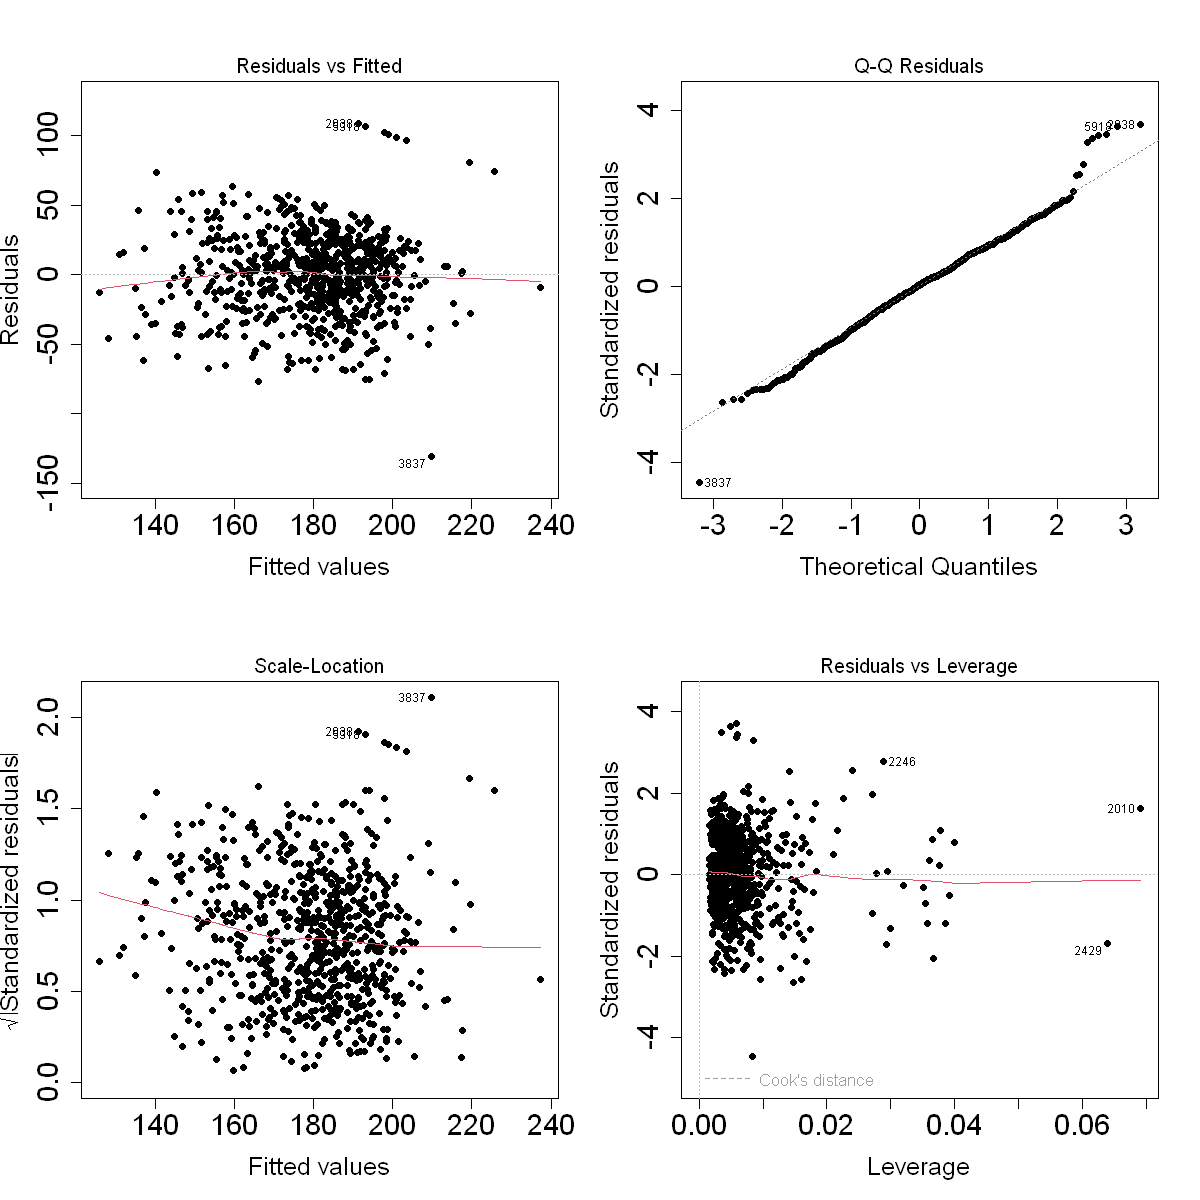

In [55]:
par(mfrow = c(2,2))
plot(fitm2, cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)
par(mfrow = c(1,1))

Es posible que algunos supuestos no se cumplan, veamos las pruebas

In [56]:
# Homocedasticidad
bptest(fitm2)


	studentized Breusch-Pagan test

data:  fitm2
BP = 1.2459, df = 4, p-value = 0.8705


In [57]:
# Incorrelacion (independencia de los errores)
dwtest(fitm2)


	Durbin-Watson test

data:  fitm2
DW = 1.87, p-value = 0.03751
alternative hypothesis: true autocorrelation is greater than 0


In [58]:
# Normalidad
# Shapiro-Wilks:
shapiro.test(residuals(fitm2))


	Shapiro-Wilk normality test

data:  residuals(fitm2)
W = 0.98991, p-value = 5.232e-05


Veamos si el problema de no normalidad se debe a valores atípicos, usemos el objeto sin _outliers_ a ver cómo resulta el modelo

In [59]:
fitm3 <- lm(RC ~ LC + IN + CC + CE, data = var.no.out)
summary(fitm3)


Call:
lm(formula = RC ~ LC + IN + CC + CE, data = var.no.out)

Residuals:
    Min      1Q  Median      3Q     Max 
-74.089 -16.888   1.574  20.012  66.581 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 92.73802    7.82155  11.857  < 2e-16 ***
LC           0.25802    0.05157   5.003 7.09e-07 ***
IN           0.14426    0.04031   3.579 0.000368 ***
CC           0.14574    0.04423   3.295 0.001032 ** 
CE          -0.05314    0.03411  -1.558 0.119653    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 26.75 on 726 degrees of freedom
Multiple R-squared:  0.1952,	Adjusted R-squared:  0.1908 
F-statistic: 44.02 on 4 and 726 DF,  p-value: < 2.2e-16


In [60]:
step(fitm3)

Start:  AIC=4810.1
RC ~ LC + IN + CC + CE

       Df Sum of Sq    RSS    AIC
<none>              519646 4810.1
- CE    1    1737.6 521383 4810.5
- CC    1    7771.6 527417 4819.0
- IN    1    9167.6 528813 4820.9
- LC    1   17914.9 537561 4832.9



Call:
lm(formula = RC ~ LC + IN + CC + CE, data = var.no.out)

Coefficients:
(Intercept)           LC           IN           CC           CE  
   92.73802      0.25802      0.14426      0.14574     -0.05314  


In [61]:
fitm4 <- lm(RC ~ LC + IN + CC , data = var.no.out)
summary(fitm4)


Call:
lm(formula = RC ~ LC + IN + CC, data = var.no.out)

Residuals:
    Min      1Q  Median      3Q     Max 
-75.104 -17.516   1.711  19.822  66.634 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 87.75743    7.14550  12.281  < 2e-16 ***
LC           0.25424    0.05157   4.930 1.02e-06 ***
IN           0.14041    0.04027   3.486 0.000519 ***
CC           0.13693    0.04391   3.119 0.001889 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 26.78 on 727 degrees of freedom
Multiple R-squared:  0.1925,	Adjusted R-squared:  0.1892 
F-statistic: 57.78 on 3 and 727 DF,  p-value: < 2.2e-16


In [62]:
AIC(fitm3, fitm4)

,df,AIC
,<dbl>,<dbl>
fitm3,6,6886.592
fitm4,5,6887.032


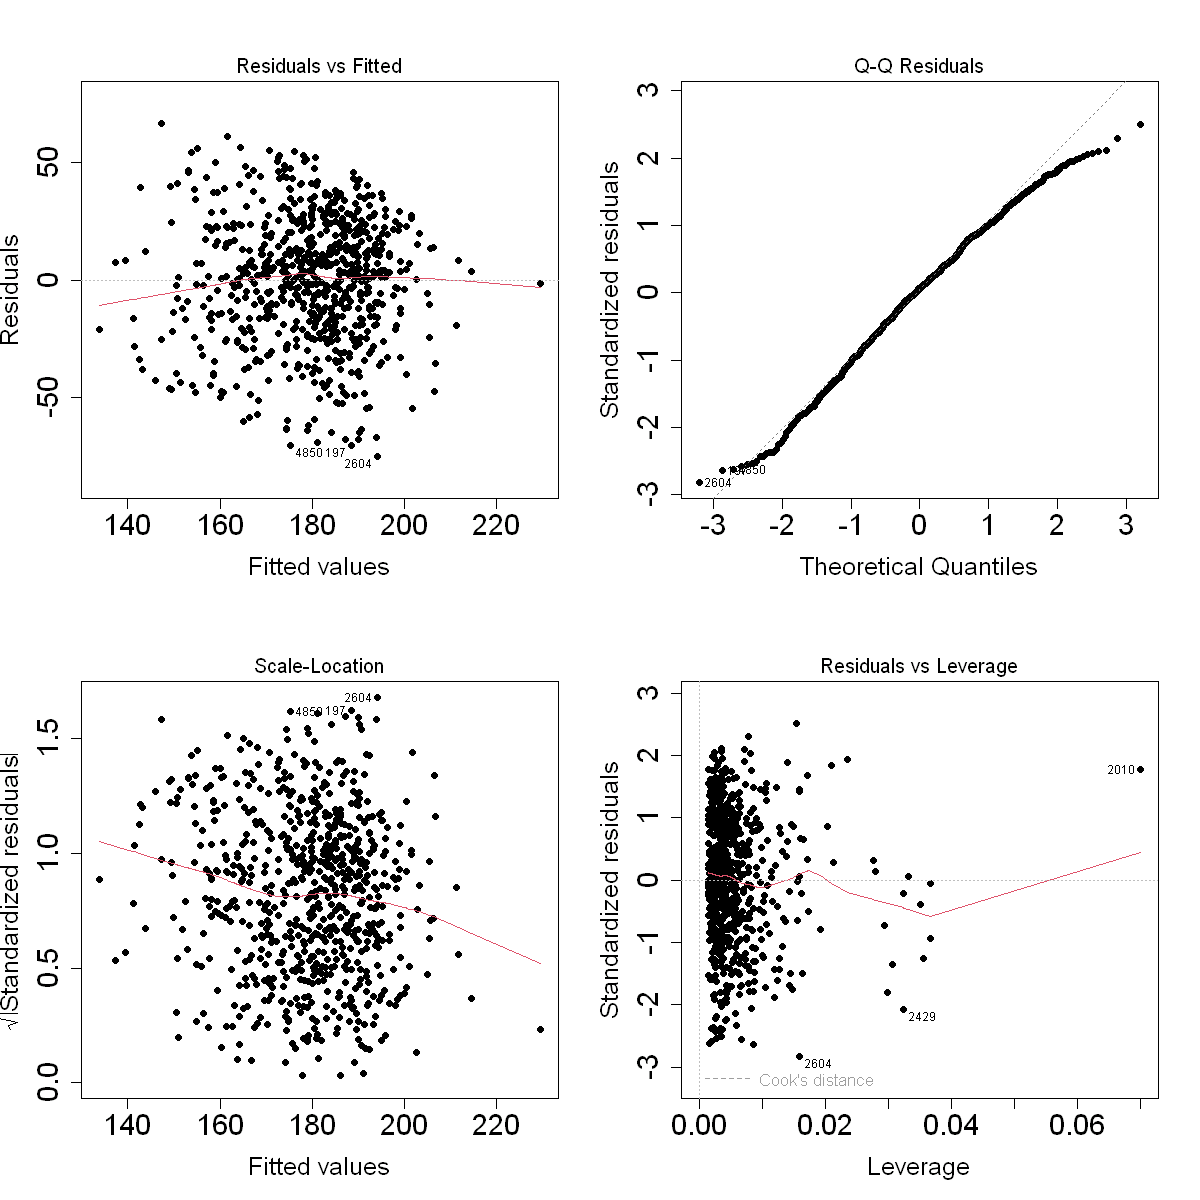

In [63]:
par(mfrow = c(2,2))
plot(fitm4, cex.lab=1.5, cex.axis=1.75, cex = 1, pch = 19, cex.main = 2)

Comprobemos supuestos

In [64]:
# Homocedasticidad
bptest(fitm4)


	studentized Breusch-Pagan test

data:  fitm4
BP = 10.855, df = 3, p-value = 0.01254


In [65]:
# Incorrelacion
dwtest(fitm4)


	Durbin-Watson test

data:  fitm4
DW = 1.9431, p-value = 0.2205
alternative hypothesis: true autocorrelation is greater than 0


In [66]:
# Normalidad
ks.test(residuals(fitm4),pnorm)


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  residuals(fitm4)
D = 0.4819, p-value < 2.2e-16
alternative hypothesis: two-sided


In [67]:
ks.test(residuals(lm(RC~LC+IN+CE+PERIODO, data = var.no.out)),pnorm)


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  residuals(lm(RC ~ LC + IN + CE + PERIODO, data = var.no.out))
D = 0.48098, p-value < 2.2e-16
alternative hypothesis: two-sided


<h2>Soluciones a problemas detectados en el diagnóstico del modelo</h2><a id='sec_soluciones'></a>

Son varias las maneras que existen para corregir los problemas de incumplimiento de hipótesis. La mayoría de éstos apuntan a reducir la heterocedasticidad ya que es ésta la principal causa de la violación de supuestos

<h3>Mínimos Cuadrados Generalizados</h3>

El método de Mínimos Cuadrados Generalizados se emplea para reducir la heterocedasticidad cuando su origen ha sido identificado. Que un modelo padezca de heterocedasticidad significa que la matriz de varianzas-covarianzas para los errores aleatorios es diagonal, con no todos sus elementos iguales:

\begin{equation}
Var \left( \epsilon \right) = E \left( \epsilon \epsilon^{\prime} \right) = G = diag \left \{ \sigma_{1}^{2}, \dots , \sigma_{n}^{2} \right\}
\end{equation}

en este caso, la log-verosimilitud del MLG tendría la forma:

\begin{equation}
L \left( \beta \right) = - \frac{1}{2} \left( y - X\beta \right)^{\prime} G^{-1}\left( y - X\beta \right)
\end{equation}

maximizarla en función de $\beta$ equivale a minimizar:

\begin{equation}
\left( y - X\beta \right)^{\prime} G^{-1}\left( y - X\beta \right)
\end{equation}

esto es

\begin{equation}
\sum_{i=1}^{n} \frac{\left( y_{i} - X_{i}^{\prime} \beta \right)^{2} }{ \sigma_{i}^{2}} = \sum_{i=1}^{n} \frac{e_{i}^{2}}{\sigma_{i}^{2}}
\end{equation}

con $X_{i}$ la i-ésima fila de la matriz de diseño $X$.\\

Lo anterior implicaría que $1/\hat{\sigma}_{i}^{2}$ representa el peso de cada una de las observaciones con lo que la ponderación de éstas permitiría reducir la heterocedasticidad.

<h3>Transformación de la Variable Respuesta</h3>

La transformación de la variable respuesta puede ser un remedio para resolver problemas de no linealidad, no normalidad, o de varianza no constante. En ocasiones, incluso alguna transformación de
la respuesta permite simplificar el modelo de predicción de un conjunto de datos.

El principal problema con estos métodos es que esta transformación no siempre soluciona los problemas encontrados y, por regla general, ocasiona otros. Resulta, además, tedioso encontrar la transformación adecuada. Sin embargo, existe un método que puede ser empleado en la mayoría de las veces y que forma parte de esa familia de \textit{transformaciones potenciales}. Es el caso de las transformaciones de Box-Cox que se pueden definir como:

\begin{equation}
z_{\lambda,i} = \left\{
\begin{aligned}
\frac{y_{i}^{\lambda} - 1}{\lambda \dot{y} ^{\lambda-1}} & \text{ si } & \lambda \neq 0, \\
\dot{y} ln \left( y_{i} \right) & \text{ si } & \lambda = 0,
\end{aligned}
\right.
\end{equation}

donde $\dot{y}$ representa la media geométrica de las observaciones.

Surge, entonces, la necesidad de estimar un nuevo parámetro $\lambda$ que permita establecer el modelo:

\begin{equation}
z_{\lambda} = X \beta + \epsilon
\end{equation}

La transformación de Box-Cox es aplicable sólo cuando la respuesta es estrictamente positiva. Si hay valores cero o negativos, la forma habitual de proceder es añadiendo una constante a la respuesta antes de aplicar el método, con el fin de hacer todos los valores positivos; sin embargo, suele haber poca información en los datos para elegir dicha constante.

<h3>Transfomación de las Covariables</h3>

Otra alternativa para corregir el incumplimiento de los supuestos básicos es realizar una transformación de las covariables. Tal como se planteó en la sección de modelos derivados del modelo logarítmos. La Tabla presenta un resumen de las posibles transformaciones de covariables.


| Transformación                                  | Regresión Simple                           | Regresión Múltiple                                      |
|-------------------------------------------------|--------------------------------------------|---------------------------------------------------------|
| $log\left( y \right) \sim log \left( X \right)$ | $y = \alpha x ^{\beta}$                    | $y = \alpha x_{1}^{\beta_{1}}\dots x_{k}^{\beta_{k}}$   |
| $log\left( y \right) \sim Y $                   | $ y = \alpha e^{\left( x \beta \right)}$   | $ y = \alpha e^{ \left\{ \sum x_{j}\beta_{j} \right\}}$ |
| $y\sim log\left( X \right)$                     | $ y = \alpha + \beta log \left( x \right)$ | $y = \alpha + \sum \beta_{j} log \left( x_{j} \right)$  |
| $1/y \sim 1/X$                                  | $y = \frac{x}{\alpha x + \beta}$           | $y = \frac{1}{\alpha + \sum \beta_{j}/x_{j}}$           |
| $1/y \sim X $                                   | $ y = \frac{1}{\alpha + \beta x}$          | $ y = \frac{1}{\alpha + \sum \beta_{j}x_{j}}$           |
| $y \sim 1/X $                                   | $y = \alpha + \beta\frac{1}{x}$            | $y = \alpha + \sum \beta_{j}\frac{1}{x_{j}}$            |


In [68]:
## probemos abordando la heterocedasticidad incluyendo un parámetro de ponderación:
res<-residuals(fitm4)
wt <- 1 / lm(abs(fitm4$residuals) ~ fitm4$fitted.values)$fitted.values^2

In [69]:
# Ya ajustamos el modelo por mcp:
fitm5<-lm(RC~LC+IN+CE+PERIODO, data = var.no.out, weights=wt)

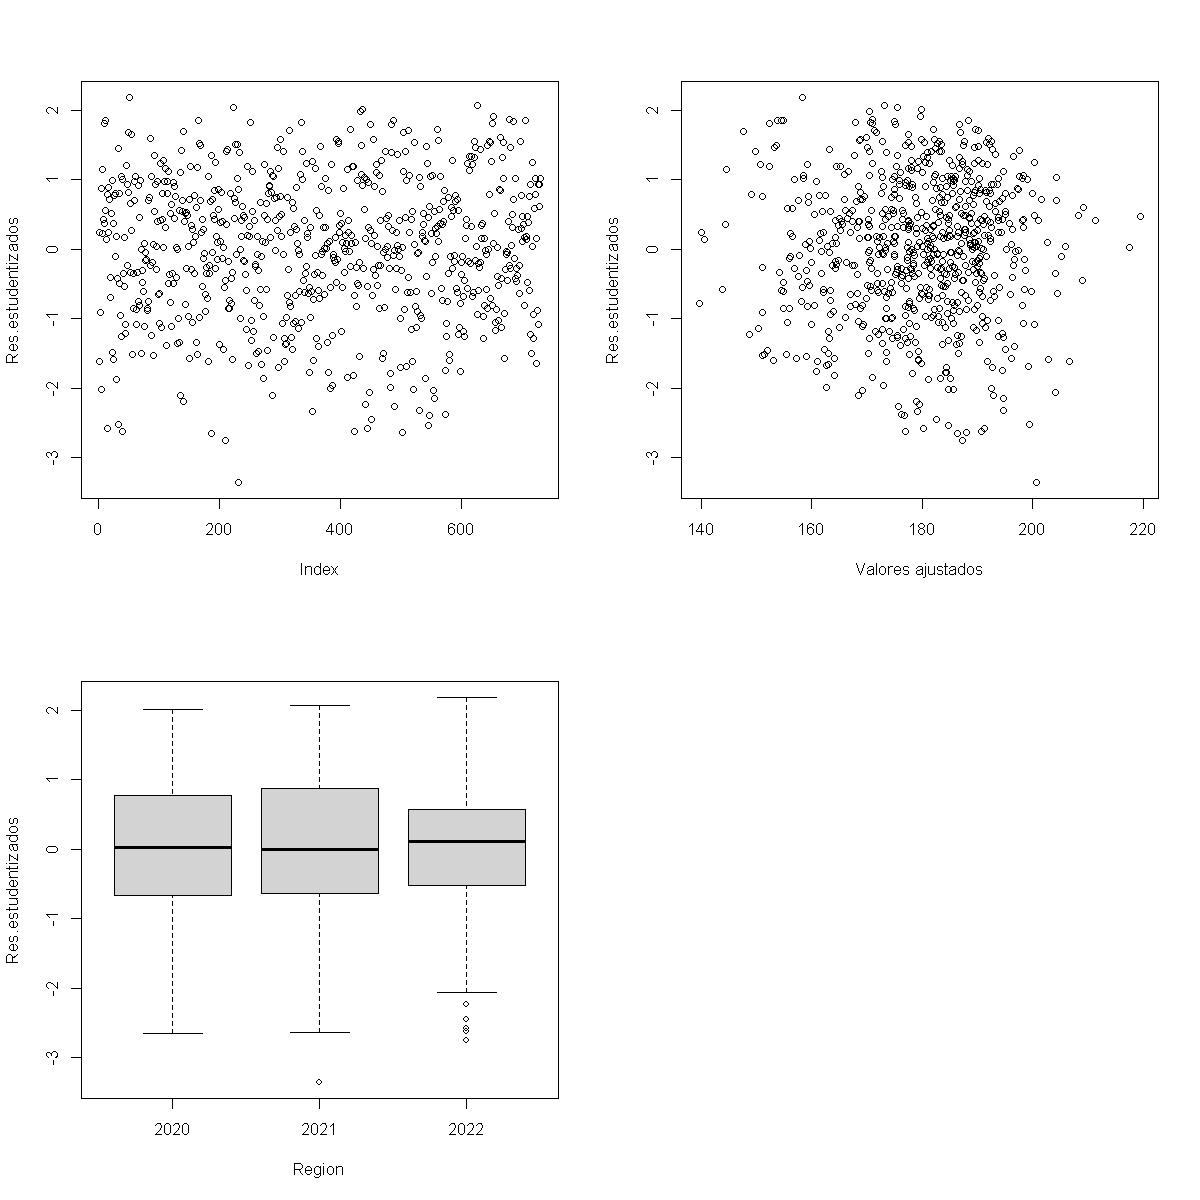

In [70]:
# y dibujamos los residuos para apreciar si hemos corregido el problema de heterocedasticidad:
r<-rstandard(fitm5)
opar<-par(mfrow=c(2,2))
plot(r,ylab='Res.estudentizados')
plot(fitted(fitm5),r,xlab='Valores ajustados', ylab='Res.estudentizados')
plot(r~var.no.out$PERIODO,xlab='Region',ylab='Res.estudentizados')
par(opar)

In [71]:
bptest(fitm5)


	studentized Breusch-Pagan test

data:  fitm5
BP = 0.57845, df = 5, p-value = 0.989


In [72]:
ks.test(rstandard(fitm5),pnorm)


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  rstandard(fitm5)
D = 0.031624, p-value = 0.4577
alternative hypothesis: two-sided


In [73]:
dwtest(fitm5,alternative='two.sided')

ERROR: Error in dwtest(fitm5, alternative = "two.sided"): weighted regressions are not supported


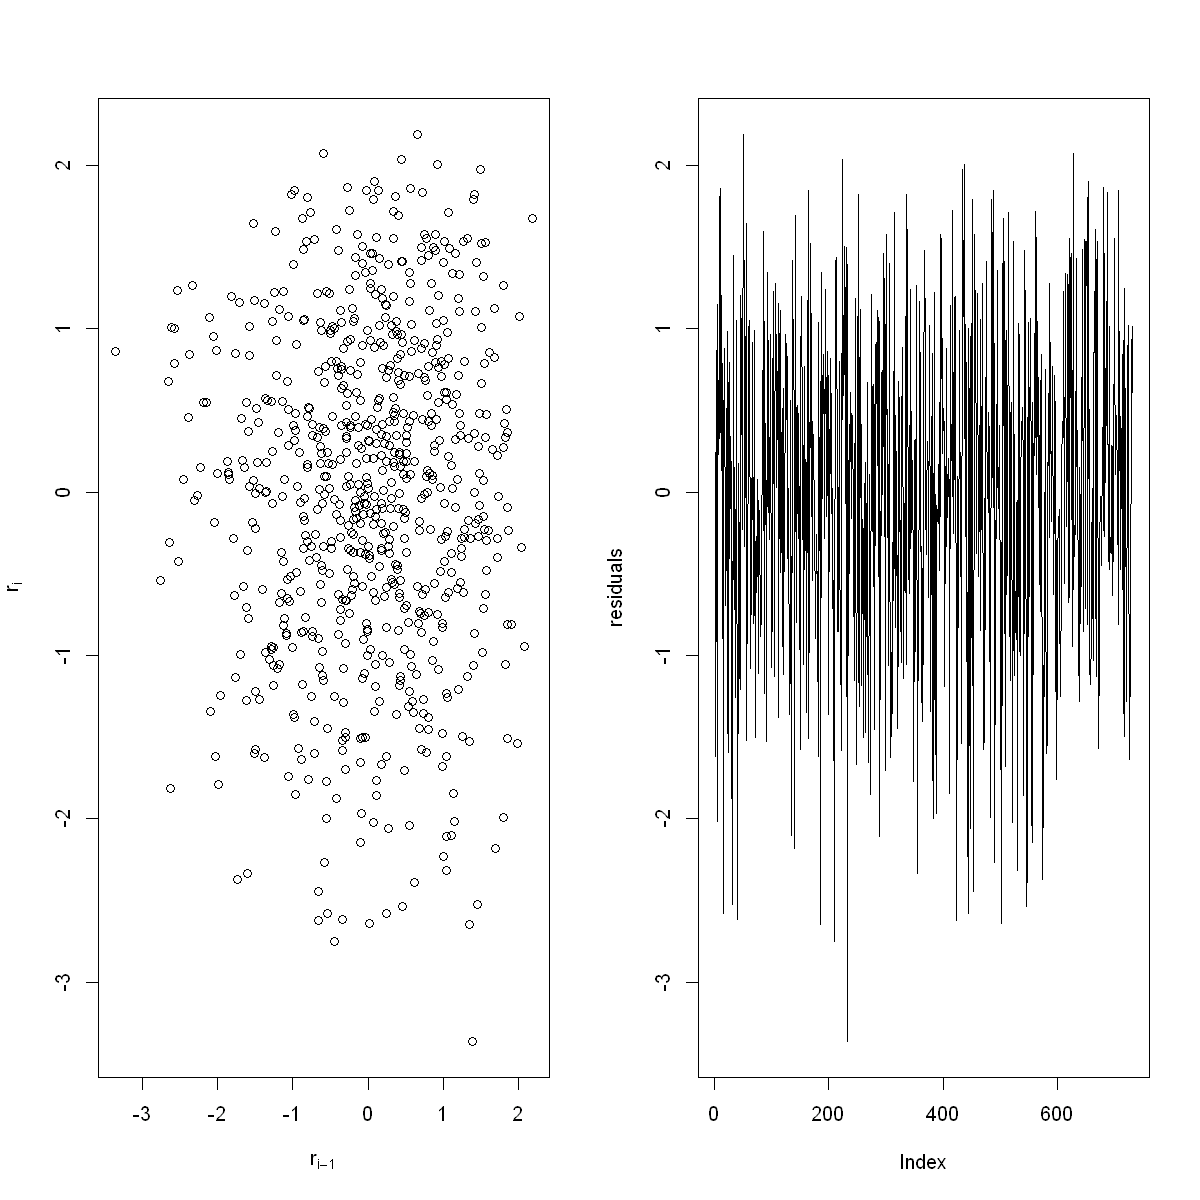

In [74]:
r<-rstandard(fitm5)
opar<-par(mfrow=c(1,2))
n<-length(r)
plot(r[2:n],r[1:(n-1)],xlab=expression(r[i-1]),ylab=expression(r[i]))
plot(r,type='l',ylab='residuals')
par(opar)

In [75]:
cor.test(r[2:n],r[1:(n-1)])


	Pearson's product-moment correlation

data:  r[2:n] and r[1:(n - 1)]
t = 0.78757, df = 728, p-value = 0.4312
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.04347865  0.10152501
sample estimates:
       cor 
0.02917668 


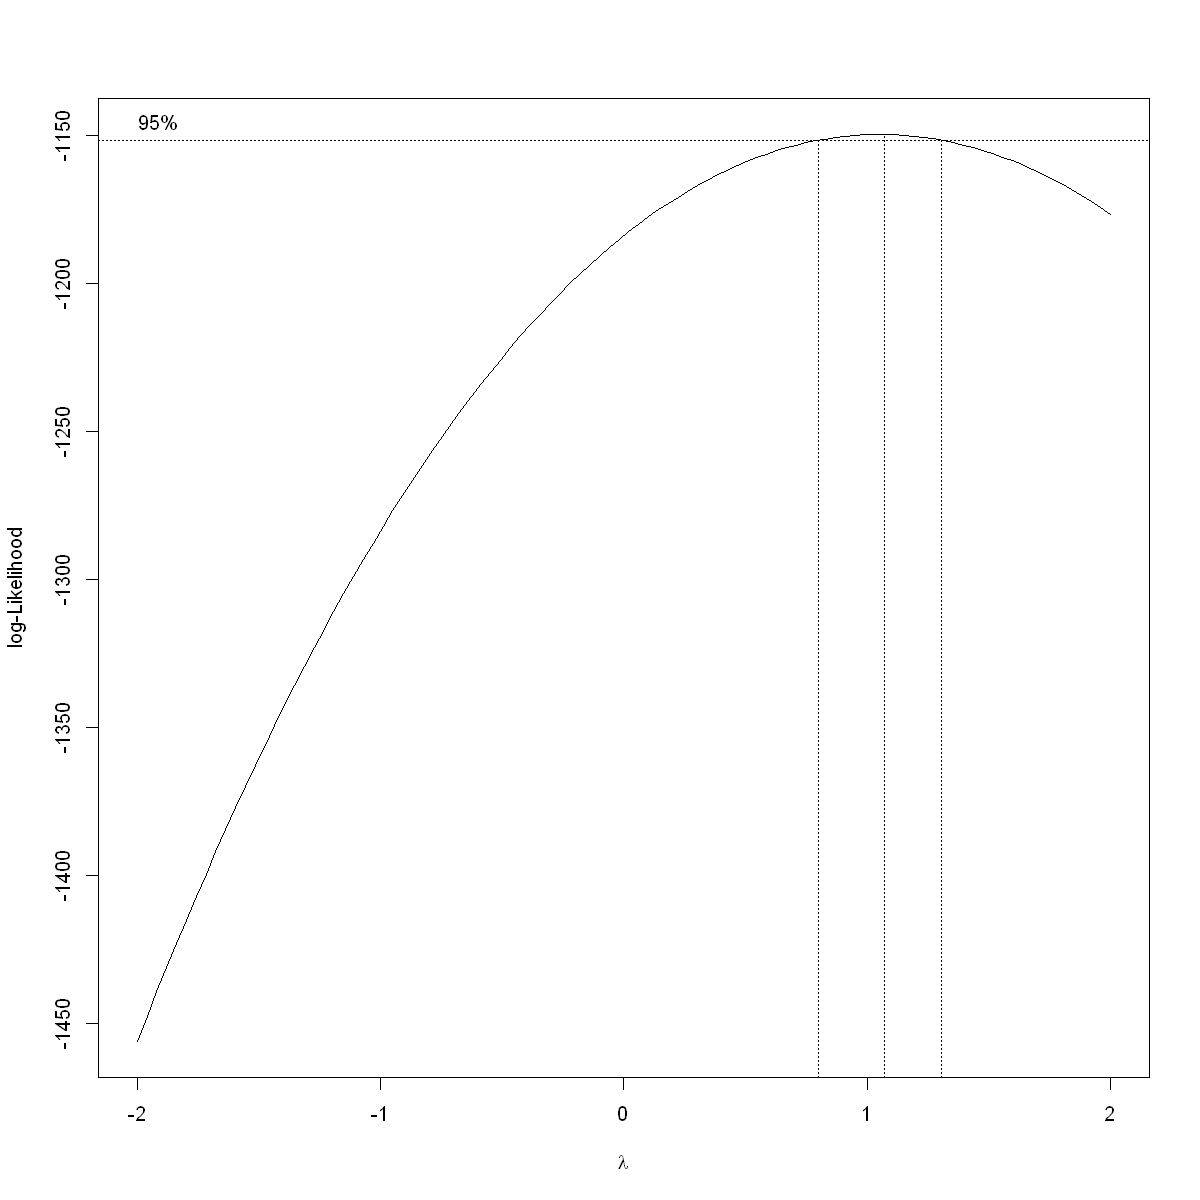

In [76]:
# Transformación de box cox

library(MASS)
boxcox(fit,plotit=T)
bc<-boxcox(fit,plotit=F)

In [77]:
lambda<-bc$x[which.max(bc$y)]; lambda

[1] 1.1

In [78]:
library(labstatR)
z <- (var.no.out$RC^lambda-1)/(lambda*meang(var.no.out$RC)^(lambda-1))

# y el nuevo ajuste con dicha variable
fit.bc <- lm(z ~ LC+IN+CE+PERIODO,data=var.no.out)
summary(fit.bc)

labstatR 1.0.13

Insieme di funzioni di supporto al volume

'Laboratorio di Statistica con R'

Iacus-Masarotto, MacGraw-Hill Italia, 2006.

Si veda 'library(help="labstatR")' per i comandi disponibili.

Nota: 'mean.a', 'mean.g' e 'hist.pf' sono state sostituite rispettivamente da 'meana', 'meang' e 'histpf'


Adjuntando el paquete: 'labstatR'


The following object is masked from 'package:survey':

    cv





Call:
lm(formula = z ~ LC + IN + CE + PERIODO, data = var.no.out)

Residuals:
   Min     1Q Median     3Q    Max 
     0      0      0      0      0 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)        0          0     NaN      NaN
LC                 0          0     NaN      NaN
IN                 0          0     NaN      NaN
CE                 0          0     NaN      NaN
PERIODO2021        0          0     NaN      NaN
PERIODO2022        0          0     NaN      NaN

Residual standard error: 0 on 725 degrees of freedom
Multiple R-squared:    NaN,	Adjusted R-squared:    NaN 
F-statistic:   NaN on 5 and 725 DF,  p-value: NA
